# Demand Forecasting and Cost-Aware Stocking Decision Support for Perishable E-Grocery
## Automatic Benchmarks vs. Manual Newsvendor Tuning

**Objective.** Evaluate whether forecast-aware, cost-aware stocking decisions can reduce estimated supply-chain penalties for 10 fast-moving Rohlik Prague_1 perishable SKUs. The notebook contrasts two **automatic** benchmarks (ARIMA and Prophet 50% default) against two **manual** newsvendor-tuned strategies (Prophet 67.2% / 63.3%).

**Interpretation note.** All financial results are scenario-based decision-support estimates, not audited Rohlik financials. The raw public data do not include on-hand inventory, order quantities, replenishment lead times, disposal records, or internal accounting costs. Therefore the financial analysis compares **forecast-based stocking policies under transparent cost assumptions**, not Rohlik's actual internal operating cost.

**How to read this notebook.** The argument runs chart -> conclusion -> next chart. Every quantitative claim is read off a figure or table; each chart is followed by a coloured **READING** box that states what the chart shows and what it lets us conclude. The main financial result emerges from comparing ARIMA, Prophet 50%, and the two cost-tuned Prophet policies under the same loss formula.

---

## Section & Figure Index

| § | Section | Figure / Table |
|---|---|---|
| §1 | Analytical Workflow | - |
| §2 | Data Scope & Reproducibility | Table 2.1, 2.2 |
| §3 | EDA & Feature Screening | **Fig 3.1**, Table 3.1 (VIF) |
| §4 | Cost Model | Table 4.1 |
| §5 | Model Architecture (Automatic vs Manual) | Table 5.1 |
| §6 | Stationarity Test (ADF) | ADF output |
| §7 | Model Training | **Fig 7.1-7.4** |
| §8 | Newsvendor Optimization Curve | **Fig 8.1** |
| §9 | Symmetric Evaluation | **Fig 9.1** |
| §10 | Statistical Significance & Residual Diagnostics | DM output, **Fig 10.1** |
| §11 | Asymmetric Financial Loss | **Fig 11.1** |
| §12 | Forecast-Strategy Metrics | Table 12.1 |
| §13 | Sensitivity Analysis | **Fig 13.1**, Table 13.1 |
| §14 | Scope of Inference | - |
| §15 | Export | json + zip |
| §16 | Reporting Conventions | - |
| §17 | References | - |


## §1 Analytical Workflow

1. **Data scope audit (§2):** verify warehouse, date range, SKU count, train/test split, and data limitations. Reproduce SKU ranking and perishability claims in-notebook from raw-source-derived files.
2. **EDA and feature screening (§3):** inspect correlations and multicollinearity without making causal claims. Select `holiday` and `total_discount` as Prophet regressors.
3. **Cost model (§4):** define asymmetric understock (€3.12) and overstock (€1.52 / €1.81) penalties as transparent scenario parameters.
4. **Four-strategy forecasting architecture (§5–§7):**
   - Two automatic benchmarks: ARIMA (univariate) and Prophet 50% (feature-aware, default central forecast).
   - Two manually tuned business strategies: Prophet Profit Max (67.2% quantile, tuned for the commercial cost ratio) and Prophet ESG (63.3% quantile, tuned for the ESG cost ratio). Both quantiles are derived from the newsvendor critical fractile.
5. **Optimization visualisation (§8):** newsvendor cost curve confirms the manual quantiles as minima of the expected total cost function.
6. **Forecast evaluation (§9–§10):** compare MAE, RMSE, sMAPE, Diebold-Mariano test results, and residual diagnostics.
7. **Financial evaluation (§11):** convert forecast errors into asymmetric understock and overstock penalties under Commercial and ESG cost scenarios.
8. **Sensitivity analysis (§13):** test whether the forecast-strategy ranking depends on one exact cost ratio by re-running under four different penalty structures.
9. **Export (§15):** bundle all poster-facing plots and a final P&L JSON into `forecasting_decision_support_assets.zip`.

<div style="background:#fff7ed;border:2px solid #ea580c;border-left:10px solid #c2410c;padding:16px 18px;border-radius:6px;margin:12px 0 18px 0">
<h3 style="color:#9a3412;margin:0 0 8px 0">IMPORTANT - RUNNING OPTIONS</h3>
<p style="margin:0 0 8px 0">Recommended: run this notebook in <b>Google Colab</b>. The next cell will pause for <b>three separate upload dialogs</b>. This is expected and does not mean the notebook is stuck.</p>
<ol style="margin:6px 0 8px 24px">
<li><code>rohlik_model_ready.csv</code></li>
<li><code>inventory.csv</code></li>
<li><code>sales_train_prague1.csv</code></li>
</ol>
<p style="margin:0 0 8px 0"><b>Please wait for each upload to finish before selecting the next file.</b> The third file is approximately 24 MB and may take longer to upload.</p>
<p style="margin:0">The saved notebook already contains complete outputs. In Colab, manual upload is required only when reproducing the analysis from scratch. For local Jupyter runs, place the three CSV files in the repository <code>data/</code> folder.</p>
</div>

In [1]:
import pandas as pd
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
import os
import json
import shutil
import io
warnings.filterwarnings('ignore')

# Create assets folder
os.makedirs('assets', exist_ok=True)

# === Three sequential upload steps ==========================================
# Each file gets its own upload dialog, in this fixed order:
#   1) rohlik_model_ready.csv
#   2) inventory.csv
#   3) sales_train_prague1.csv   (~17 MB — Prague_1-only subset, 3 cols)
# The third file is the pre-filtered Prague_1 slice of the raw sales_train.csv;
# this keeps the upload small while still letting cell-5 reproduce the per-uid
# sales ranking from a raw-source-derived file. If the uploaded filename does
# not match the expected one, the cell raises immediately so the mismatch is
# obvious instead of silently mis-wired.
def _upload_one(expected_name, local_candidates):
    """Colab: one ``files.upload()`` per file. Local: try disk paths."""
    try:
        from google.colab import files  # only present in Colab
    except ImportError:
        path = next((p for p in local_candidates if os.path.exists(p)), None)
        if path is None:
            raise FileNotFoundError(
                "{} not found. Looked in: {}".format(expected_name, local_candidates))
        if os.path.basename(path) != expected_name:
            raise FileNotFoundError(
                "Expected '{}' but resolved to '{}' on disk. Please re-run this cell.".format(
                    expected_name, path))
        print("Loaded {} from {}".format(expected_name, path))
        return pd.read_csv(path)

    # Colab path (reached only when the ``from google.colab import files`` above
    # succeeded).
    print("Upload '{}'".format(expected_name))
    uploaded = files.upload()
    if expected_name not in uploaded:
        raise FileNotFoundError(
            "Expected '{}' but got {}. Please re-run this cell.".format(
                expected_name, sorted(uploaded.keys())))
    return pd.read_csv(io.BytesIO(uploaded[expected_name]))


df             = _upload_one(
    'rohlik_model_ready.csv',
    ['data/rohlik_model_ready.csv',
     '../data/rohlik_model_ready.csv',
     'rohlik_model_ready.csv'])

inventory_df   = _upload_one(
    'inventory.csv',
    ['data/inventory.csv',
     '../data/inventory.csv',
     'inventory.csv',
     'raw_data/inventory.csv',
     '../../M1_Production&Logistic_Management/raw_data/inventory.csv',
     '../M1_Production&Logistic_Management/raw_data/inventory.csv'])

sales_train_df = _upload_one(
    'sales_train_prague1.csv',
    ['data/sales_train_prague1.csv',
     '../data/sales_train_prague1.csv',
     'sales_train_prague1.csv',
     'raw_data/sales_train_prague1.csv',
     '../../M1_Production&Logistic_Management/raw_data/sales_train_prague1.csv',
     '../M1_Production&Logistic_Management/raw_data/sales_train_prague1.csv'])

print("rohlik_model_ready.csv: {:,} rows".format(len(df)))
print("inventory.csv:          {:,} rows".format(len(inventory_df)))
print("sales_train_prague1.csv (Prague_1 only, 3 cols): {:,} rows".format(len(sales_train_df)))
# ============================================================================

df['date'] = pd.to_datetime(df['date'])

# Filter for the target warehouse
df_w = df[df['warehouse'] == 'Prague_1'].sort_values('date').copy()

# Daily Aggregation
df_daily = df_w.groupby('date').agg({
    'sales': 'sum',
    'total_discount': 'sum',
    'holiday': 'max',
    'sell_price_main': 'mean',
    'availability': 'mean'
}).asfreq('D')

# Train/Test Split (Strict Chronological)
train = df_daily[df_daily.index <= '2023-12-31'].copy()
test = df_daily[df_daily.index > '2023-12-31'].copy()

# Time-Series Continuity (Linear Interpolation for missing days)
train['sales'] = train['sales'].interpolate(method='linear')
test['sales'] = test['sales'].interpolate(method='linear')

train.fillna(0, inplace=True)
test.fillna(0, inplace=True)

print(f"Training Shape: {train.shape} | Testing Shape: {test.shape}")

Upload 'rohlik_model_ready.csv'


Saving rohlik_model_ready.csv to rohlik_model_ready.csv
Upload 'inventory.csv'


Saving inventory.csv to inventory.csv
Upload 'sales_train_prague1.csv'


Saving sales_train_prague1.csv to sales_train_prague1.csv
rohlik_model_ready.csv: 13,958 rows
inventory.csv:          5,432 rows
sales_train_prague1.csv (Prague_1 only, 3 cols): 780,566 rows
Training Shape: (1248, 5) | Testing Shape: (154, 5)


## §2 Data Scope and Reproducibility

10 selected Prague_1 SKUs, 154-day out-of-sample test (**2024-01-01 to 2024-06-02**). Table 2.1 audits the scope; Table 2.2 reproduces the top-10 SKU ranking and perishable categories directly from the raw Kaggle files (`inventory.csv` + `sales_train_prague1.csv`), so no external lookup is needed.

Important data limitation: the raw public files contain sales, availability, price, discount, calendar, and product-category fields, but no true inventory-position data such as on-hand stock, order quantities, replenishment lead times, or disposal/waste records. For that reason, this final notebook does **not** claim a reconstructed operating baseline cost; the financial comparison is limited to forecast-based strategies evaluated under the same transparent loss formula.


In [2]:
import pandas as pd

# --- Data Scope Audit ---
# Uses the same df loaded in cell-2 — no need to re-read from disk.
# The assertion protects against accidentally running this cell before cell-2.
assert 'df' in globals(), "df not found — please run cell-2 first."

date_min = df['date'].min()
date_max = df['date'].max()
unique_ids = sorted(df['unique_id'].unique())
warehouses = sorted(df['warehouse'].unique())

df_daily_audit = (
    df[df['warehouse'] == 'Prague_1']
    .groupby('date')
    .agg(
        sales=("sales", "sum"),
        total_discount=("total_discount", "sum"),
        holiday=("holiday", "max"),
        sell_price_main=("sell_price_main", "mean"),
        availability=("availability", "mean"),
    )
    .asfreq("D")
)
train_audit = df_daily_audit[df_daily_audit.index <= "2023-12-31"]
test_audit = df_daily_audit[df_daily_audit.index > "2023-12-31"]

scope_table = pd.DataFrame(
    [
        ["Raw CSV date range", f"{date_min.date()} to {date_max.date()}"],
        ["Warehouse(s)", ", ".join(warehouses)],
        ["Number of selected unique_id values", len(unique_ids)],
        ["Selected unique_id values", ", ".join(map(str, unique_ids))],
        ["Training period", f"{train_audit.index.min().date()} to {train_audit.index.max().date()} ({len(train_audit)} days)"],
        ["Testing period", f"{test_audit.index.min().date()} to {test_audit.index.max().date()} ({len(test_audit)} days)"],
    ],
    columns=["Audit item", "Value"],
)
display(scope_table)


,Audit item,Value
0,Raw CSV date range,2020-08-01 to 2024-06-02
1,Warehouse(s),Prague_1
2,Number of selected unique_id values,10
3,Selected unique_id values,"525, 652, 2159, 2562, 2937, 3144, 3616, 4228, ..."
4,Training period,2020-08-01 to 2023-12-31 (1248 days)
5,Testing period,2024-01-01 to 2024-06-02 (154 days)


In [3]:
# --- Auditable Evidence: SKU Sales Volume Ranks and Categories ---
# inventory_df and sales_train_df were loaded once in §1 alongside
# rohlik_model_ready.csv — no second upload is required.
#
# sales_train_df here is the pre-filtered Prague_1-only subset
# (sales_train_prague1.csv, ~17 MB, 3 columns: unique_id / date / sales)
# derived from the raw Kaggle sales_train.csv by filtering warehouse ==
# 'Prague_1'. This keeps the upload small while preserving the audit trail
# back to the raw source file.

assert 'inventory_df' in globals(), "inventory_df missing — re-run §1."
assert 'sales_train_df' in globals(), "sales_train_df missing — re-run §1."

unique_ids_ready = sorted(df['unique_id'].unique())

df_inv_prague1 = inventory_df[inventory_df['warehouse'] == 'Prague_1']
prague1_uids = set(df_inv_prague1['unique_id'])

# Aggregate per-uid sales across the entire raw training history. The
# Prague_1-only subset (~780k rows, 3 columns) fits comfortably in memory.
sales_sums = sales_train_df.groupby('unique_id')['sales'].sum().to_dict()

p1_sales = []
for uid in prague1_uids:
    row = inventory_df[inventory_df['unique_id'] == uid].iloc[0]
    p1_sales.append({
        'unique_id': uid,
        'name':      row['name'],
        'category':  row['L1_category_name_en'],
        'sales':     sales_sums.get(uid, 0),
    })

df_p1_sales = (pd.DataFrame(p1_sales)
                 .sort_values(by='sales', ascending=False)
                 .reset_index(drop=True))
df_p1_sales['rank'] = df_p1_sales.index + 1

print("--- Verified Prague_1 SKU Sales Volume Rankings and Categories ---")
print("(Reproduced in-notebook from inventory.csv + sales_train_prague1.csv)")
for uid in unique_ids_ready:
    row = df_p1_sales[df_p1_sales['unique_id'] == uid]
    if not row.empty:
        r = row.iloc[0]
        print("UID {:>5} | Name: {:12s} | Category: {:20s} | Rank: {:>3} of {}".format(
            int(r['unique_id']), r['name'], r['category'],
            int(r['rank']), len(df_p1_sales)))

--- Verified Prague_1 SKU Sales Volume Rankings and Categories ---
(Reproduced in-notebook from inventory.csv + sales_train_prague1.csv)
UID   525 | Name: Roll_8       | Category: Bakery               | Rank:   4 of 863
UID   652 | Name: Cucumber_10  | Category: Fruit and vegetable  | Rank:   2 of 863
UID  2159 | Name: Roll_20      | Category: Bakery               | Rank:   7 of 863
UID  2562 | Name: Banana_10    | Category: Fruit and vegetable  | Rank:   6 of 863
UID  2937 | Name: Bread_113    | Category: Bakery               | Rank:   8 of 863
UID  3144 | Name: Bread_122    | Category: Bakery               | Rank:   5 of 863
UID  3616 | Name: Bread_143    | Category: Bakery               | Rank:   9 of 863
UID  4228 | Name: Radish_13    | Category: Fruit and vegetable  | Rank:  10 of 863
UID  4879 | Name: Roll_56      | Category: Bakery               | Rank:   3 of 863
UID  4885 | Name: Roll_57      | Category: Bakery               | Rank:   1 of 863


## §3 Exploratory Data Analysis and Feature Screening

The EDA is descriptive. Pearson correlation identifies linear association, not causality. VIF is used only to inspect multicollinearity among candidate regressors; it does not prove statistical independence.

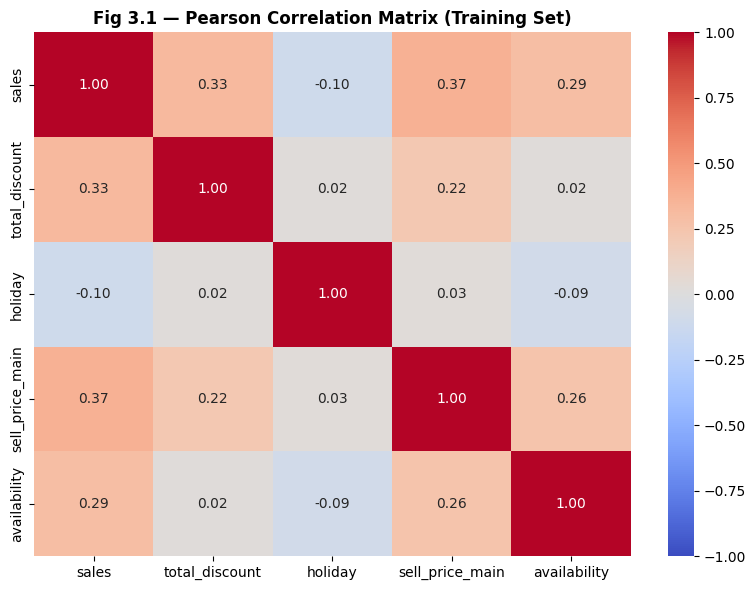

Observed linear associations (Pearson r, training set):
  sales ~ total_discount: r = +0.33
  sales ~ holiday:        r = -0.10

These are descriptive linear associations on the training set only. They do not imply causation and are not used to justify any structural claim; they motivate the inclusion of total_discount and holiday as Prophet regressors.


In [4]:
# Correlation Matrix
corr = train[['sales', 'total_discount', 'holiday', 'sell_price_main', 'availability']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Fig 3.1 — Pearson Correlation Matrix (Training Set)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('assets/plot_eda_correlation.png', dpi=300)
plt.show()

print("Observed linear associations (Pearson r, training set):")
print(f"  sales ~ total_discount: r = {corr.loc['sales', 'total_discount']:+.2f}")
print(f"  sales ~ holiday:        r = {corr.loc['sales', 'holiday']:+.2f}")
print(
    "\nThese are descriptive linear associations on the training set only. "
    "They do not imply causation and are not used to justify any structural claim; "
    "they motivate the inclusion of total_discount and holiday as Prophet regressors."
)

## §3.1 Feature Selection and Modeling Inputs

The final Prophet regressors are `holiday` and `total_discount`. `sell_price_main` is excluded from the final model because its incremental contribution is weak and it may be partly endogenous to demand or promotion decisions. This is a modeling choice, not a VIF-based removal.

In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Variance Inflation Factor (VIF) for the candidate regressors.
# VIF_j = 1 / (1 - R_j^2), where R_j^2 is the coefficient of determination
# obtained by regressing predictor j on all other predictors. A VIF near 1
# indicates negligible *linear* dependence on the other regressors; common
# rules of thumb flag VIF > 5 (moderate) or VIF > 10 (severe) collinearity.
X_raw = train[['total_discount', 'holiday', 'sell_price_main']].fillna(0)
X_raw = add_constant(X_raw)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_raw.columns
vif_data["VIF_Score"] = [variance_inflation_factor(X_raw.values, i) for i in range(X_raw.shape[1])]

print("Variance Inflation Factor (VIF) Analysis:")
print(vif_data.to_string(index=False))
print(
    "\nInterpretation: all predictor VIF scores are close to 1.0 and well below "
    "the conventional threshold of 5, indicating no material multicollinearity "
    "among the candidate regressors. Note that low VIF rules out linear "
    "redundancy only; it does not establish statistical independence or the "
    "absence of nonlinear association."
)

Variance Inflation Factor (VIF) Analysis:
       Variable  VIF_Score
          const  52.721838
 total_discount   1.052312
        holiday   1.001143
sell_price_main   1.052841

Interpretation: all predictor VIF scores are close to 1.0 and well below the conventional threshold of 5, indicating no material multicollinearity among the candidate regressors. Note that low VIF rules out linear redundancy only; it does not establish statistical independence or the absence of nonlinear association.


In [6]:
# Feature Engineering: Isolating Core Predictors
features = ['holiday', 'total_discount']
target = 'sales'

# We prepare the exact clean dataset required for Modeling
train_clean = train[[target] + features].reset_index().rename(columns={'date': 'ds', 'sales': 'y'})
test_clean = test[[target] + features].reset_index().rename(columns={'date': 'ds', 'sales': 'y'})

train_clean.head()


,ds,y,holiday,total_discount
0,2020-08-01,76288.45,0,5.95490
1,2020-08-02,84847.07,0,5.95490
2,2020-08-03,73316.39,0,1.14282
3,2020-08-04,63434.77,0,1.14282
4,2020-08-05,65010.12,0,1.14282


## §4 Cost Model and Scenario Assumptions

The financial evaluation uses an asymmetric loss function. In grocery retail, **under-forecasting** (lost sales) and **over-forecasting** (spoilage) carry different costs, so a symmetric error metric like RMSE does not capture the true business impact.

### Cost parameters (scenario assumptions, not Rohlik-confirmed)

| Parameter | Value | Status | Interpretation |
|---|---:|---:|---|
| Understock penalty ($C_u$) | €3.12/unit | Scenario assumption | 30% gross-margin loss on average selling price of ~€10.40 |
| Commercial overstock penalty | €1.52/unit | Scenario assumption | Spoilage / overage loss only |
| ESG overstock penalty | €1.81/unit | Scenario assumption | €1.52 spoilage + €0.29 ESG disposal surcharge |

### What is the ESG surcharge?

**ESG** (Environmental, Social, and Governance) reporting is mandated for large EU companies under the **CSRD** (Corporate Sustainability Reporting Directive). The €0.29/unit disposal surcharge is a scenario parameter that internalizes the estimated environmental cost of food waste — landfill emissions, disposal logistics, and regulatory compliance overhead. It is not a Rohlik-confirmed cost; it is a transparent scenario assumption tested for robustness in the sensitivity analysis (§13).

These parameters feed directly into the newsvendor quantile derivation in §5.

In [7]:
# Define Corporate Financial Constants for both scenarios
# 1. Commercial Scenario (Standard)
PENALTY_OVER_COMM = 1.52  # Commercial Spoilage
# 2. ESG Scenario (Environmental disposal fee included)
PENALTY_OVER_ESG = 1.81   # 1.52 Spoilage + 0.29 ESG disposal fee

PENALTY_UNDER = 3.12 # Lost Margin Profit


## §5 Forecasting Models: Architecture and Rationale

We train **four forecasting strategies**, not one. They differ in whether they use external features (holidays, promotions) and in how they handle the fundamental overstock/understock trade-off.

---

### 1. Two automatic benchmarks (no manual tuning)

| # | Model | Features | Quantile | Role |
|---|---|---|---|---|
| 1 | ARIMA(7,1,1) | None (univariate) | — | Traditional ERP benchmark: can a simple time-series model suffice? |
| 2 | Prophet 50% | holiday, total_discount | 50% (default) | Feature-aware benchmark: does adding promotion and calendar data improve accuracy? |

ARIMA(7,1,1) is retained as a fixed, transparent benchmark specification. The weekly lag motivates $p=7$, while §6 reports the ADF result separately. The notebook does not claim that ADF selects the complete ARIMA order or that $d=1$ is required by the test.

These two are **automatic**: no quantile tuning, no cost-awareness. They answer: *is Prophet better than ARIMA, holding everything else equal?*

---

### 2. Two manually tuned business strategies — the newsvendor logic

In grocery retail, forecast errors are **asymmetric**: ordering too little loses a sale (margin lost forever), while ordering too much creates spoilage (product + disposal cost). A point forecast at the 50th percentile ignores this asymmetry — it treats overstock and understock as equally painful, which they are not.

The **newsvendor model** (also called the newsboy problem) is the classic operations-management framework for this exact situation: you must order perishable inventory before demand is known, and the two errors have different costs. The optimal order quantity corresponds to a specific forecast quantile — the **critical fractile**:

$$Q^* = \frac{C_u}{C_u + C_o}$$

where:

- $C_u$ = **underage cost** (cost of ordering one unit too few) = lost profit margin = **€3.12/unit**
- $C_o$ = **overage cost** (cost of ordering one unit too many) = spoilage loss + optional disposal fee

The critical fractile answers: *at what quantile should we set the forecast so that the expected cost of ordering one more unit equals the expected cost of ordering one fewer?* Below this quantile, stocking more reduces expected total cost; above it, stocking less does.

We compute two quantiles from two different overage costs, producing two distinct business strategies:

#### Strategy A — Prophet Profit Max (Commercial cost ratio)

Uses the **commercial overage cost** (spoilage only, no disposal fee):

$$C_o = \text{€1.52/unit}$$

$$Q^* = \frac{3.12}{3.12 + 1.52} = \frac{3.12}{4.64} = 0.6724 \approx \mathbf{67.2\%}$$

**Business intent:** maximize profit by aggressively avoiding stockouts. When spoilage is the only overage penalty, the cost of missing a sale (€3.12) is roughly double the cost of wasting a unit (€1.52), so the optimal bias is strongly upward.

#### Strategy B — Prophet ESG (ESG cost ratio)

Uses the **ESG overage cost** (spoilage + disposal fee):

$$C_o = \text{€1.52 (spoilage)} + \text{€0.29 (ESG disposal fee)} = \text{€1.81/unit}$$

$$Q^* = \frac{3.12}{3.12 + 1.81} = \frac{3.12}{4.93} = 0.6329 \approx \mathbf{63.3\%}$$

**Business intent:** balance profit against environmental responsibility. **ESG** (Environmental, Social, and Governance) criteria are increasingly mandated by EU regulation (CSRD) and investor disclosure requirements. The €0.29/unit disposal surcharge reflects the estimated environmental cost of food waste — landfill emissions, transport to disposal, and regulatory compliance. When this cost is internalized, the overage penalty rises from €1.52 to €1.81, and the optimal quantile **drops from 67.2% to 63.3%** — a less aggressive overstocking posture that trades slightly higher stockout risk for measurably lower waste.

#### Summary

| # | Strategy | $C_u$ | $C_o$ | Formula | Quantile | Prophet `interval_width` | Business intent |
|---|---:|---:|---:|---|---|---|
| 3 | Prophet Profit Max | €3.12 | €1.52 | 3.12/4.64 | **67.2%** | 0.345 | Maximize profit; accept more waste |
| 4 | Prophet ESG | €3.12 | €1.81 | 3.12/4.93 | **63.3%** | 0.266 | Balance profit + ESG compliance; reduce waste |

**How Prophet implements the quantile choice.** Prophet's `yhat_upper` with `interval_width = w` approximates the $(1 + w)/2$ quantile of the predictive distribution (e.g., default $w = 0.8$ gives the 90th percentile). To target a specific quantile $q$, set $w = 2q - 1$:

- Profit Max: $q = 0.672$ → $w = 2 \times 0.672 - 1 = 0.344 \approx \mathbf{0.345}$
- ESG: $q = 0.632$ → $w = 2 \times 0.632 - 1 = \mathbf{0.266}$

This is an uncertainty-interval approximation to the target quantile under Prophet's predictive distribution, not an empirical quantile-regression estimate. Both policy forecasts are extracted from the same fitted Prophet model and the same seeded uncertainty draws, so their comparison isolates the quantile choice. Realized coverage may still deviate from the nominal quantile.

These two strategies answer: *given the same Prophet engine, can we tune the forecast quantile to a specific business objective (profit maximization vs. ESG-balanced operations) and measurably reduce the estimated penalty in each cost scenario?*

**Important caveat.** This notebook does not model multi-period lead times, supplier constraints, stochastic replenishment, or product substitution. The quantile choice is a single-period newsvendor heuristic — it illustrates the principle that cost structure should inform forecast usage, but it is not a production inventory system.

**§8 visualises the cost curve** that confirms 67.2% and 63.3% sit at the minima of their respective total-cost functions.

## §6 Stationarity Diagnostic (ADF)

The Augmented Dickey-Fuller (ADF) test checks the training series for a unit root. The result is reported as a diagnostic rather than used to retroactively justify the fixed ARIMA(7,1,1) benchmark. If p < 0.05, we reject the unit-root null at the 5% level; otherwise, we fail to reject it. ADF alone does not select the complete $(p,d,q)$ order.

In [8]:
from statsmodels.tsa.stattools import adfuller

# Stationarity diagnostic on the training series
adf_stat, adf_p, *_ = adfuller(train['sales'].dropna())
print(f"ADF statistic: {adf_stat:.3f} | p-value: {adf_p:.4f}")
if adf_p < 0.05:
    adf_conclusion = "Reject the unit-root null at 5%: the training series is stationary by this ADF test."
else:
    adf_conclusion = "Fail to reject the unit-root null at 5%: the ADF test does not establish stationarity."
print(adf_conclusion)
print("ARIMA(7,1,1) remains a fixed benchmark specification; this ADF result alone does not select d or the full order.")

ADF statistic: -2.948 | p-value: 0.0401
Reject the unit-root null at 5%: the training series is stationary by this ADF test.
ARIMA(7,1,1) remains a fixed benchmark specification; this ADF result alone does not select d or the full order.


## §7 Model Training and Diagnostic Plots

We now fit all four strategies on the training set and generate the diagnostic plots (Fig 7.1–7.4). The reading that follows interprets them.

Training ARIMA...
Training one Prophet forecasting base...


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Extracting Prophet Profit Max policy (67.2% quantile)...
Extracting Prophet ESG policy (63.3% quantile)...

--- Generating and Saving Diagnostic Plots ---
Generating Fig 7.1: Prophet Components...


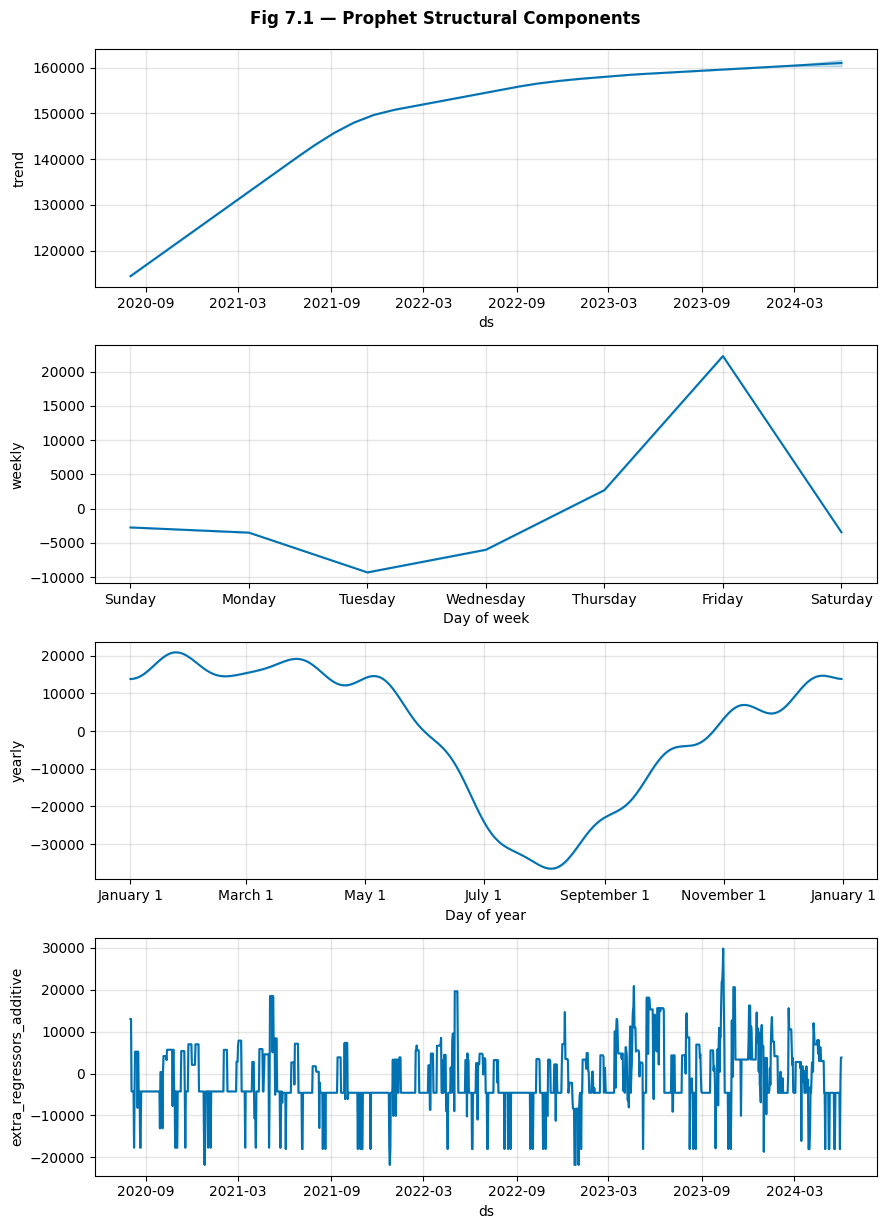

Generating Fig 7.2: Training Fit...


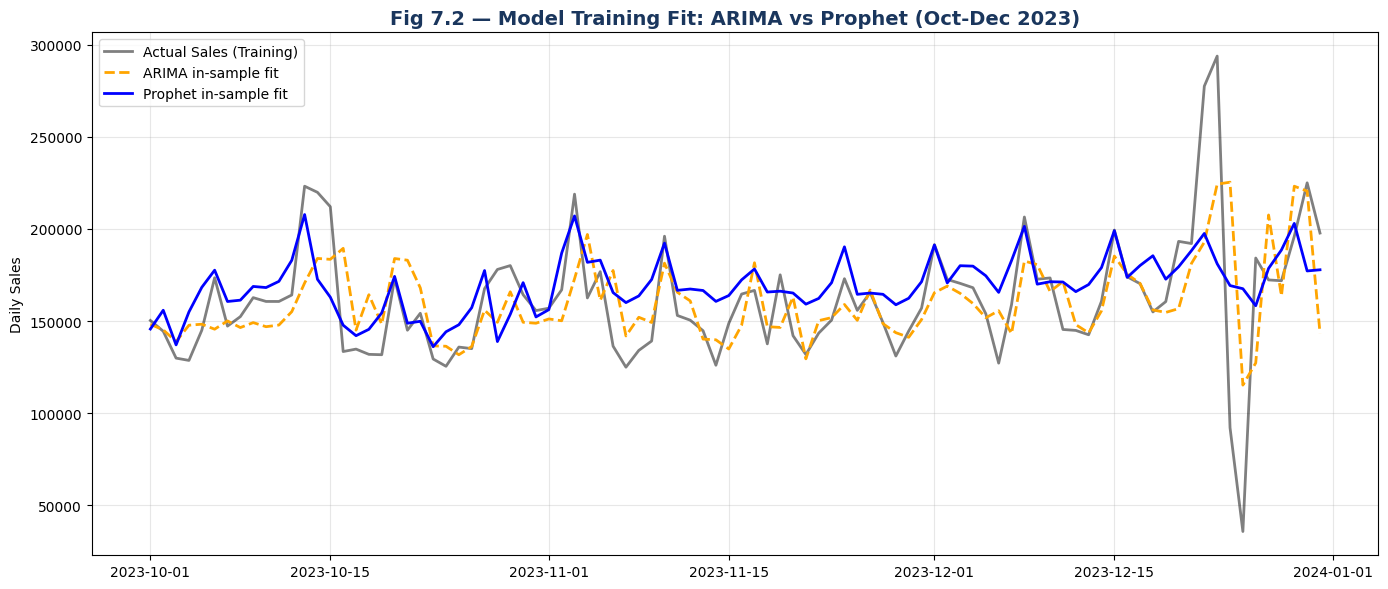

Generating Fig 7.3: Output Validation...


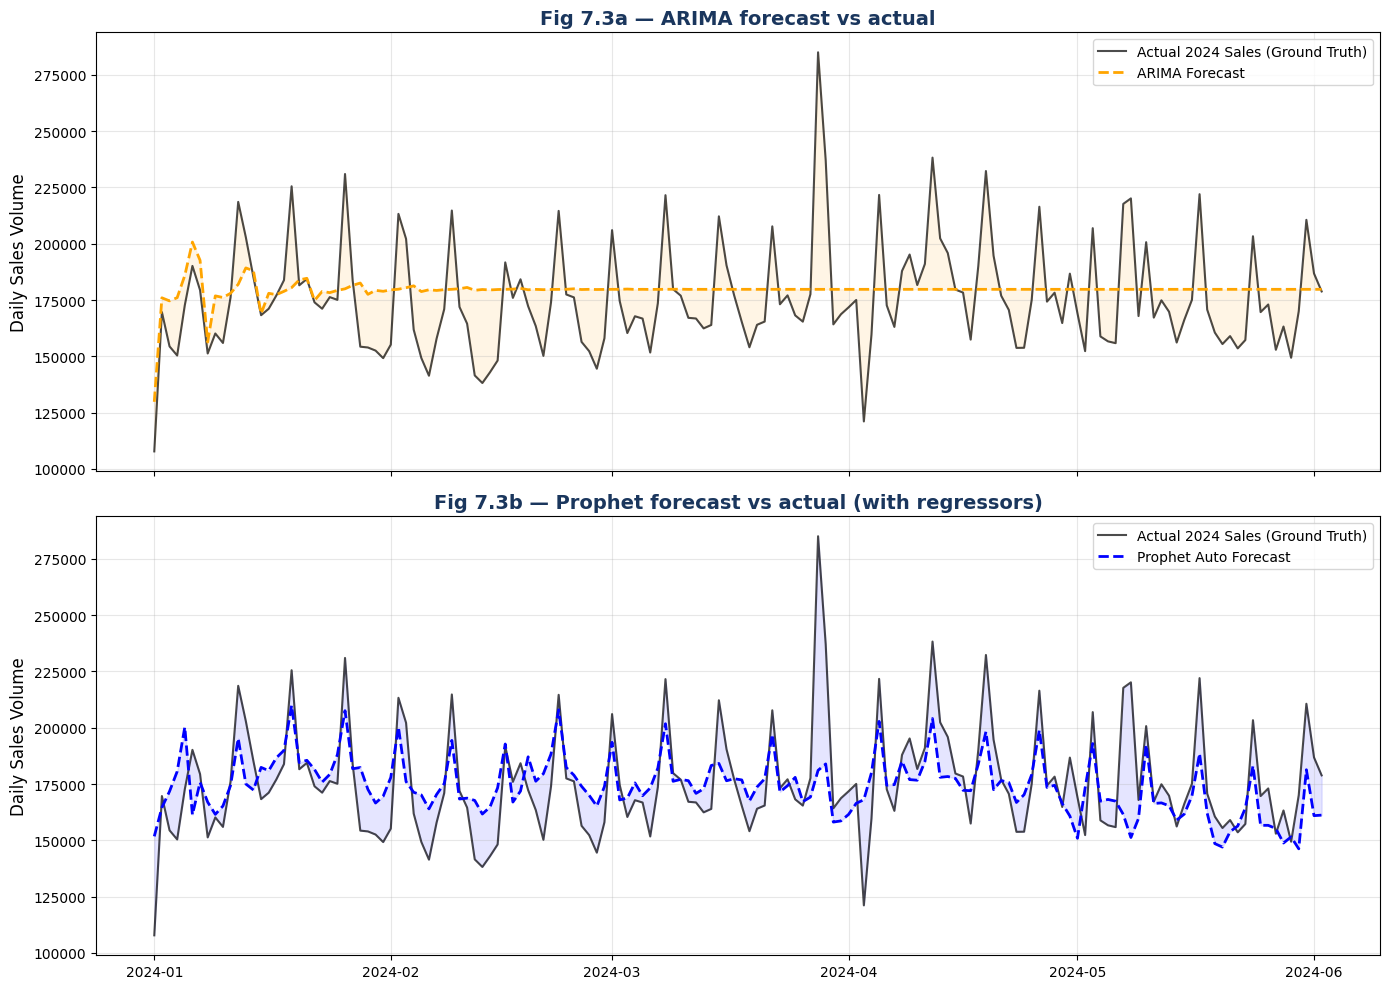

Generating Fig 7.4: 3-Way Quantiles...


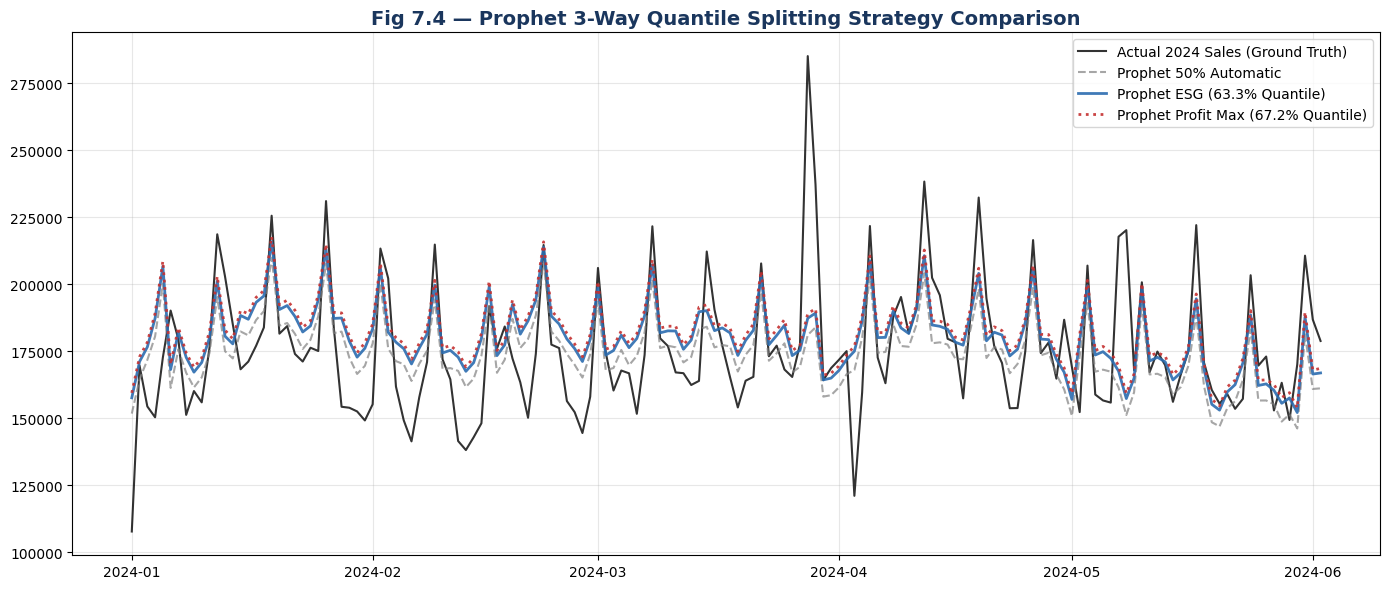

In [9]:
import numpy as np
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Prophet requires specific column names, and since 'date' is the index, we must reset_index() first
train_p = train.reset_index().rename(columns={'date': 'ds', 'sales': 'y'})
test_p = test.reset_index().rename(columns={'date': 'ds', 'sales': 'y'})

# 1. ARIMA Benchmark
print("Training ARIMA...")
sarima_model = SARIMAX(train['sales'], order=(7, 1, 1), seasonal_order=(0, 0, 0, 0))
sarima_results = sarima_model.fit(disp=False)
preds_arima = sarima_results.forecast(steps=len(test)).values

# 2. One fitted Prophet forecasting base
print("Training one Prophet forecasting base...")
m_auto = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    changepoint_prior_scale=0.01,
    uncertainty_samples=2000,
)
m_auto.add_regressor('holiday')
m_auto.add_regressor('total_discount')
m_auto.fit(train_p)

# The 50% strategy uses Prophet's central yhat point forecast.
np.random.seed(42)
auto_forecast = m_auto.predict(test_p)
preds_auto = auto_forecast['yhat'].values

# 3-4. Cost-aware policies: extract two upper quantiles from the same fitted
# model and the same uncertainty draws. This isolates policy choice from model
# re-fitting noise and makes repeated runs reproducible.
Q_PROFIT_MAX = PENALTY_UNDER / (PENALTY_UNDER + PENALTY_OVER_COMM)
Q_ESG = PENALTY_UNDER / (PENALTY_UNDER + PENALTY_OVER_ESG)
QUANTILE_SEED = 42

def predict_upper_quantile(fitted_model, future, quantile, seed=QUANTILE_SEED):
    original_width = fitted_model.interval_width
    fitted_model.interval_width = 2 * quantile - 1
    np.random.seed(seed)
    forecast = fitted_model.predict(future)
    fitted_model.interval_width = original_width
    return forecast['yhat_upper'].values

print(f"Extracting Prophet Profit Max policy ({Q_PROFIT_MAX:.1%} quantile)...")
preds_opt = predict_upper_quantile(m_auto, test_p, Q_PROFIT_MAX)

print(f"Extracting Prophet ESG policy ({Q_ESG:.1%} quantile)...")
preds_esg = predict_upper_quantile(m_auto, test_p, Q_ESG)

# A higher quantile from identical draws must never fall below a lower one.
assert np.all(preds_opt >= preds_esg), "Quantile ordering failed: 67.2% must be >= 63.3% pointwise"

actuals = test['sales'].values

print("\n--- Generating and Saving Diagnostic Plots ---")

# --- Fig 7.1: Prophet Structural Components ---
print("Generating Fig 7.1: Prophet Components...")
forecast_full = m_auto.predict(pd.concat([train_p, test_p]))
fig_comp = m_auto.plot_components(forecast_full)
fig_comp.suptitle('Fig 7.1 — Prophet Structural Components', fontweight='bold', y=1.02)
fig_comp.savefig('assets/prophet_components_native.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Fig 7.2: Training Fit Diagnostic ---
print("Generating Fig 7.2: Training Fit...")
train_subset = train[(train.index >= '2023-10-01') & (train.index <= '2023-12-31')]
arima_train_preds = sarima_results.predict(start='2023-10-01', end='2023-12-31')
subset_clean = train_subset.reset_index().rename(columns={'date': 'ds'})
prophet_train_preds = m_auto.predict(subset_clean[['ds', 'holiday', 'total_discount']])['yhat'].values

plt.figure(figsize=(14, 6))
plt.plot(train_subset.index, train_subset['sales'], label='Actual Sales (Training)', color='black', alpha=0.5, linewidth=2)
plt.plot(train_subset.index, arima_train_preds, label='ARIMA in-sample fit', color='orange', linestyle='--', linewidth=2)
plt.plot(train_subset.index, prophet_train_preds, label='Prophet in-sample fit', color='blue', linewidth=2)
plt.title('Fig 7.2 — Model Training Fit: ARIMA vs Prophet (Oct-Dec 2023)', fontweight='bold', fontsize=14, color='#1a365d')
plt.ylabel('Daily Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('assets/plot_training_fit.png', dpi=300)
plt.show()

# --- Fig 7.3: Model Output Validation ---
print("Generating Fig 7.3: Output Validation...")
test_dates = test.index
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax1.plot(test_dates, actuals, label='Actual 2024 Sales (Ground Truth)', color='black', alpha=0.7, linewidth=1.5)
ax1.plot(test_dates, preds_arima, label='ARIMA Forecast', color='orange', linestyle='--', linewidth=2)
ax1.set_title('Fig 7.3a — ARIMA forecast vs actual', fontsize=14, fontweight='bold', color='#1a365d')
ax1.set_ylabel('Daily Sales Volume', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.fill_between(test_dates, actuals, preds_arima, color='orange', alpha=0.1)

ax2.plot(test_dates, actuals, label='Actual 2024 Sales (Ground Truth)', color='black', alpha=0.7, linewidth=1.5)
ax2.plot(test_dates, preds_auto, label='Prophet Auto Forecast', color='blue', linestyle='--', linewidth=2)
ax2.set_title('Fig 7.3b — Prophet forecast vs actual (with regressors)', fontsize=14, fontweight='bold', color='#1a365d')
ax2.set_ylabel('Daily Sales Volume', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.fill_between(test_dates, actuals, preds_auto, color='blue', alpha=0.1)

plt.tight_layout()
plt.savefig('assets/plot_arima_vs_prophet.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Fig 7.4: Prophet 3-Way Splitting ---
print("Generating Fig 7.4: 3-Way Quantiles...")
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test_dates, actuals, label='Actual 2024 Sales (Ground Truth)', color='black', alpha=0.8, linewidth=1.5)
ax.plot(test_dates, preds_auto, label='Prophet 50% Automatic', color='gray', linestyle='--', alpha=0.7)
ax.plot(test_dates, preds_esg, label='Prophet ESG (63.3% Quantile)', color='#2b6cb0', alpha=0.9, linewidth=2)
ax.plot(test_dates, preds_opt, label='Prophet Profit Max (67.2% Quantile)', color='#c53030', linestyle=':', alpha=0.9, linewidth=2)
ax.set_title('Fig 7.4 — Prophet 3-Way Quantile Splitting Strategy Comparison', fontweight='bold', fontsize=14, color='#1a365d')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('assets/plot_3way_test.png', dpi=300, bbox_inches='tight')
plt.show()

<div style="background:#ebf8ff;border-left:6px solid #2b6cb0;padding:12px 18px;border-radius:4px">
<b style="color:#1a365d;font-size:15px">READING - Fig 7.1-7.4: visual diagnostics before formal evaluation</b>
<ul style="margin:8px 0 0 0">
<li><b>Fig 7.1 (components):</b> inspect the weekly and yearly patterns learned by Prophet. These are model components, not causal effects.</li>
<li><b>Fig 7.2 (training fit):</b> this is an in-sample diagnostic only; it cannot establish out-of-sample superiority.</li>
<li><b>Fig 7.3 (out-of-sample):</b> compare how ARIMA and Prophet follow the 154 observed test days. §9 quantifies the visible differences and §10 tests the ARIMA-vs-Prophet accuracy gap.</li>
<li><b>Fig 7.4 (policy quantiles):</b> the 67.2% line must be at or above the 63.3% line, and both are above the central 50% strategy because they are extracted from the same seeded Prophet predictive distribution.</li>
</ul>
<b style="color:#1a365d">Conclusion:</b> these plots check model behaviour and quantile ordering. The numerical winners are determined only by the computed metrics and losses below.
</div>

## §8 Newsvendor Cost Optimisation: Visualising the Target Forecast Quantile

The newsvendor critical fractile (§5) is the analytical minimum of the expected total cost function. Below, we sweep target forecast quantiles from 50% to 99% and plot expected daily cost under both the Commercial and ESG cost structures. The curve uses the **training-set** demand mean and standard deviation for scale, so the 154-day test set remains reserved for evaluation. The optimum itself comes from the cost ratio $C_u/(C_u+C_o)$, not from tuning against test outcomes.

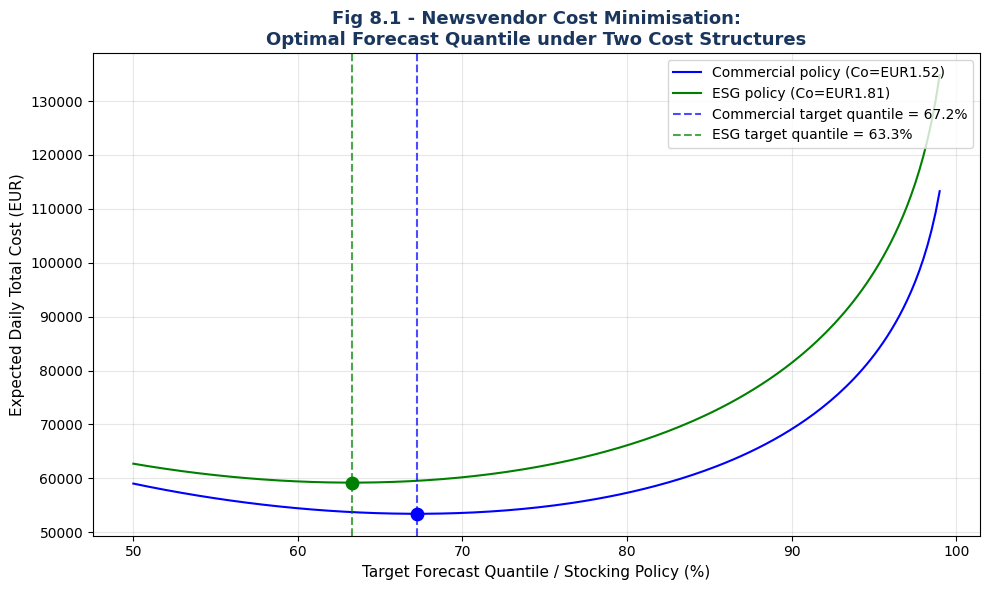

Commercial critical fractile: Cu/(Cu+Co) = 3.12/(3.12+1.52) = 67.2%
ESG critical fractile: Cu/(Cu+Co) = 3.12/(3.12+1.81) = 63.3%


In [10]:
import scipy.stats as sp_stats

# Demand distribution: use training-set daily sales only to scale the curve.
# The public data do not include true inventory positions, so the curve is a
# single-period newsvendor scenario, not a full replenishment simulation.
mu_demand = train['sales'].mean()
sigma_demand = train['sales'].std()

# Sweep target forecast quantiles
q_range = np.linspace(0.50, 0.99, 200)

def compute_expected_costs(q_array, Cu, Co, mu, sigma):
    """Expected daily underage + overage cost for each target forecast quantile."""
    total = []
    for q in q_array:
        Q = sp_stats.norm.ppf(q, loc=mu, scale=sigma)
        z = (Q - mu) / sigma
        exp_over = sigma * (z * sp_stats.norm.cdf(z) + sp_stats.norm.pdf(z))
        exp_under = sigma * (sp_stats.norm.pdf(z) - z * (1 - sp_stats.norm.cdf(z)))
        total.append(Co * exp_over + Cu * exp_under)
    return np.array(total)

costs_comm = compute_expected_costs(q_range, PENALTY_UNDER, PENALTY_OVER_COMM, mu_demand, sigma_demand)
costs_esg  = compute_expected_costs(q_range, PENALTY_UNDER, PENALTY_OVER_ESG, mu_demand, sigma_demand)

# Optimal critical fractiles / target forecast quantiles
opt_q_comm = PENALTY_UNDER / (PENALTY_UNDER + PENALTY_OVER_COMM)
opt_q_esg  = PENALTY_UNDER / (PENALTY_UNDER + PENALTY_OVER_ESG)
idx_comm = np.argmin(np.abs(q_range - opt_q_comm))
idx_esg  = np.argmin(np.abs(q_range - opt_q_esg))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(q_range * 100, costs_comm, 'b-', linewidth=1.5, label='Commercial policy (Co=EUR1.52)')
ax.plot(q_range * 100, costs_esg, 'g-', linewidth=1.5, label='ESG policy (Co=EUR1.81)')
ax.axvline(opt_q_comm * 100, color='b', linestyle='--', alpha=0.7,
           label=f'Commercial target quantile = {opt_q_comm:.1%}')
ax.axvline(opt_q_esg * 100, color='g', linestyle='--', alpha=0.7,
           label=f'ESG target quantile = {opt_q_esg:.1%}')
ax.scatter([opt_q_comm * 100], [costs_comm[idx_comm]], color='blue', s=80, zorder=5)
ax.scatter([opt_q_esg * 100], [costs_esg[idx_esg]], color='green', s=80, zorder=5)

ax.set_xlabel('Target Forecast Quantile / Stocking Policy (%)', fontsize=11)
ax.set_ylabel('Expected Daily Total Cost (EUR)', fontsize=11)
ax.set_title('Fig 8.1 - Newsvendor Cost Minimisation:\nOptimal Forecast Quantile under Two Cost Structures',
             fontweight='bold', fontsize=13, color='#1a365d')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('assets/plot_optimization_curve.png', dpi=300)
plt.show()

print(f"Commercial critical fractile: Cu/(Cu+Co) = {PENALTY_UNDER}/({PENALTY_UNDER}+{PENALTY_OVER_COMM}) = {opt_q_comm:.1%}")
print(f"ESG critical fractile: Cu/(Cu+Co) = {PENALTY_UNDER}/({PENALTY_UNDER}+{PENALTY_OVER_ESG}) = {opt_q_esg:.1%}")

<div style="background:#ebf8ff;border-left:6px solid #2b6cb0;padding:12px 18px;border-radius:4px">
<b style="color:#1a365d;font-size:15px">READING - Fig 8.1: the target quantile is the minimum of a cost curve</b>
<ul style="margin:8px 0 0 0">
<li>Both curves are <b>U-shaped and convex</b>: moving the target forecast quantile upward first cuts cost (fewer stockouts), bottoms out, then rises (spoilage takes over).</li>
<li>The marked minima land <b>exactly on the analytical fractiles - 67.2% (Commercial), 63.3% (ESG)</b>. These are target forecast quantiles for comparing stocking policies.</li>
<li>The <b>ESG curve (green) sits above Commercial (blue)</b> everywhere - the EUR1.81 vs EUR1.52 overage cost makes every overstocked unit dearer.</li>
<li>Adding the ESG surcharge <b>shifts the optimum left (67.2% -> 63.3%)</b>: penalise waste more, hold less safety stock.</li>
</ul>
<b style="color:#1a365d">-> Conclusion:</b> this is the optimisation in the project title - the operating quantile is <i>located</i> as a curve minimum, not asserted. §9-§11 measure what it is worth in euros.
</div>


## §9 Forecast Accuracy - Symmetric Metrics

We evaluate all four forecast-based strategies on the 154-day test set in two layers:

- **Layer 1 - symmetric metrics (here):** MAE, RMSE, and sMAPE treat over- and under-forecasting symmetrically and identify which strategy is numerically closest to realized sales.
- **Layer 2 - asymmetric cost (§11):** under-forecast and over-forecast errors receive different scenario penalties and identify which tested policy has the lowest estimated loss.

The 67.2% and 63.3% strategies are designed for asymmetric decision costs, so their symmetric-error ranking is an empirical result, not something assumed in advance.

--- Standard Symmetric Forecast Evaluation Metrics (Out-of-Sample) ---


,Model,MAE,RMSE,sMAPE (%)
0,ARIMA Benchmark,"18,359.92","23,736.95",10.26%
1,Prophet 50% Automatic,"14,332.64","19,636.67",8.11%
2,Prophet Profit Max (67.2% Quantile),"15,755.07","20,608.69",8.91%
3,Prophet ESG (63.3% Quantile),"15,126.30","20,110.16",8.56%


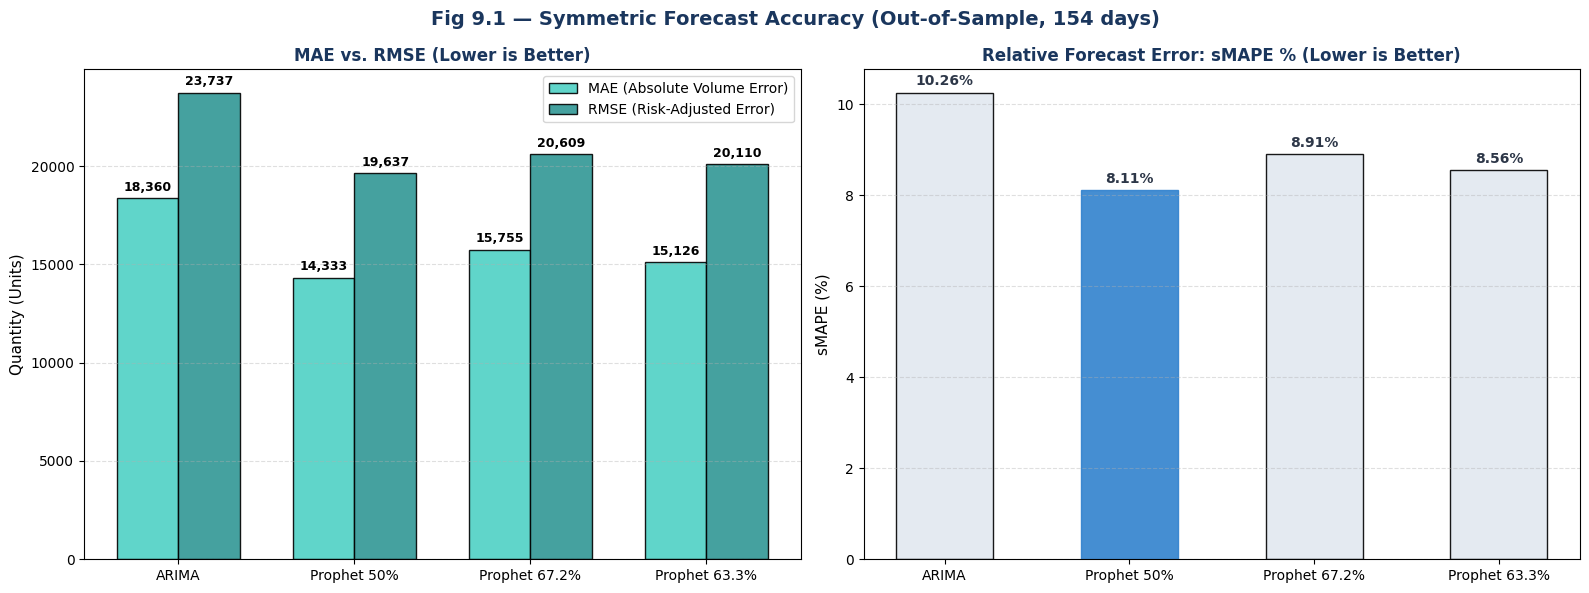

In [11]:
# Standard Symmetric Forecast Evaluation Metrics (Out-of-Sample)
from sklearn.metrics import mean_absolute_error, mean_squared_error

def get_standard_metrics(preds, name):
    mae_val = mean_absolute_error(actuals, preds)
    rmse_val = np.sqrt(mean_squared_error(actuals, preds))

    # Calculate sMAPE
    denominator = (np.abs(actuals) + np.abs(preds)) / 2.0
    diff = np.abs(actuals - preds) / denominator
    diff[denominator == 0] = 0.0
    smape_val = 100.0 * np.mean(diff)

    return {
        'Model': name,
        'MAE': mae_val,
        'RMSE': rmse_val,
        'sMAPE (%)': smape_val
    }

metrics_list = [
    get_standard_metrics(preds_arima, 'ARIMA Benchmark'),
    get_standard_metrics(preds_auto, 'Prophet 50% Automatic'),
    get_standard_metrics(preds_opt, 'Prophet Profit Max (67.2% Quantile)'),
    get_standard_metrics(preds_esg, 'Prophet ESG (63.3% Quantile)')
]

df_metrics = pd.DataFrame(metrics_list)

# Format the output for nicer display in Jupyter
df_metrics_styled = df_metrics.copy()
df_metrics_styled['MAE'] = df_metrics_styled['MAE'].map('{:,.2f}'.format)
df_metrics_styled['RMSE'] = df_metrics_styled['RMSE'].map('{:,.2f}'.format)
df_metrics_styled['sMAPE (%)'] = df_metrics_styled['sMAPE (%)'].map('{:.2f}%'.format)

print("--- Standard Symmetric Forecast Evaluation Metrics (Out-of-Sample) ---")
display(df_metrics_styled)


# --- Plot Symmetric Metrics (Grouped Bar Chart & Percentage Error) ---
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Fig 9.1 — Symmetric Forecast Accuracy (Out-of-Sample, 154 days)', fontweight='bold', fontsize=14, color='#1a365d')

models = ['ARIMA', 'Prophet 50%', 'Prophet 67.2%', 'Prophet 63.3%']
mae_vals = df_metrics['MAE'].values
rmse_vals = df_metrics['RMSE'].values
smape_vals = df_metrics['sMAPE (%)'].values

# Left Plot: MAE & RMSE (Grouped Bar Chart)
x = np.arange(len(models))
width = 0.35

rects1 = ax1.bar(x - width/2, mae_vals, width, label='MAE (Absolute Volume Error)', color='#4fd1c5', edgecolor='black', alpha=0.9)
rects2 = ax1.bar(x + width/2, rmse_vals, width, label='RMSE (Risk-Adjusted Error)', color='#319795', edgecolor='black', alpha=0.9)

ax1.set_title('MAE vs. RMSE (Lower is Better)', fontweight='bold', fontsize=12, color='#1a365d')
ax1.set_ylabel('Quantity (Units)', fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=10)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# Label helper
def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:,.0f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='semibold')

autolabel(rects1, ax1)
autolabel(rects2, ax1)

# Right Plot: sMAPE (%)
rects3 = ax2.bar(models, smape_vals, width*1.5, label='sMAPE (%)', color='#e2e8f0', edgecolor='black', alpha=0.9)
# Highlight the lowest-sMAPE model in blue
best_idx = int(np.argmin(smape_vals))
for idx, rect in enumerate(rects3):
    if idx == best_idx:
        rect.set_color('#3182ce')

ax2.set_title('Relative Forecast Error: sMAPE % (Lower is Better)', fontweight='bold', fontsize=12, color='#1a365d')
ax2.set_ylabel('sMAPE (%)', fontsize=11)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

# Label percentages
for rect in rects3:
    height = rect.get_height()
    ax2.annotate(f'{height:.2f}%',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold', color='#2d3748')

plt.tight_layout()
plt.savefig('assets/plot_symmetric_metrics.png', dpi=300)
plt.show()

In [12]:
from IPython.display import display, HTML

metric_winners = {
    metric: df_metrics.loc[df_metrics[metric].idxmin(), 'Model']
    for metric in ['MAE', 'RMSE', 'sMAPE (%)']
}
unique_metric_winners = list(dict.fromkeys(metric_winners.values()))
metric_winner = unique_metric_winners[0] if len(unique_metric_winners) == 1 else "Different strategies win different metrics"

arima_row = df_metrics.set_index('Model').loc['ARIMA Benchmark']
auto_row = df_metrics.set_index('Model').loc['Prophet 50% Automatic']
improvements = {
    metric: (arima_row[metric] - auto_row[metric]) / arima_row[metric] * 100
    for metric in ['MAE', 'RMSE', 'sMAPE (%)']
}

winner_items = "".join(
    f"<li><b>{metric} winner:</b> {winner} ({df_metrics.loc[df_metrics[metric].idxmin(), metric]:,.2f})</li>"
    for metric, winner in metric_winners.items()
)

display(HTML(f"""
<div style="background:#ebf8ff;border-left:6px solid #2b6cb0;padding:12px 18px;border-radius:4px">
<b style="color:#1a365d;font-size:15px">READING - Fig 9.1: symmetric accuracy from this run</b>
<ul style="margin:8px 0 0 0">
{winner_items}
<li><b>Prophet 50% vs ARIMA:</b> MAE {improvements['MAE']:+.1f}%, RMSE {improvements['RMSE']:+.1f}%, and sMAPE {improvements['sMAPE (%)']:+.1f}% improvement (positive means lower error).</li>
</ul>
<b style="color:#1a365d">Conclusion:</b> {metric_winner}. Symmetric accuracy does not determine the asymmetric-cost winner; §11 computes that separately from the same forecasts.
</div>
"""))

## §10 Statistical Significance and Residual Diagnostics

Before relying on the accuracy gap seen in §7 and §9, we test it formally. The Diebold-Mariano test asks whether the ARIMA-vs-Prophet difference is statistically significant; the residual ACF and Ljung-Box test check whether each model leaves predictable structure behind.

In [13]:
# §10 Diebold-Mariano Test
from scipy.stats import norm, t
import numpy as np

def dm_test(actual, pred1, pred2, h=1):
    """Diebold-Mariano test, squared-error loss, HAC long-run variance.
    H0: equal predictive accuracy. Uses Harvey-Leybourne-Newbold small-sample
    correction."""
    e1 = np.asarray(actual) - np.asarray(pred1)
    e2 = np.asarray(actual) - np.asarray(pred2)
    d = e1**2 - e2**2
    n = len(d)
    d_mean = d.mean()
    gamma0 = np.sum((d - d_mean)**2) / n
    lrv = gamma0
    for k in range(1, h):
        cov = np.sum((d[k:] - d_mean) * (d[:-k] - d_mean)) / n
        lrv += 2 * (1 - k / h) * cov
    dm_stat = d_mean / np.sqrt(lrv / n)
    corr = np.sqrt((n + 1 - 2*h + h*(h-1)/n) / n)
    dm_stat *= corr
    pval = 2 * (1 - t.cdf(abs(dm_stat), df=n - 1))
    return dm_stat, pval

dm_stat, dm_pval = dm_test(actuals, preds_arima, preds_auto, h=1)
print("--- §10 Diebold-Mariano Test (squared-error loss, h=1) ---")
print(f"DM Statistic: {dm_stat:.4f} | p-value: {dm_pval:.4e}")
print("H0: ARIMA and Prophet have equal out-of-sample predictive accuracy.")
if dm_pval < 0.05:
    better = "Prophet" if np.mean((actuals-preds_auto)**2) < np.mean((actuals-preds_arima)**2) else "ARIMA"
    print(f"Reject H0 at 5%: the accuracy difference is statistically significant ({better} lower MSE).")
else:
    print("Fail to reject H0 at 5%: no statistically significant accuracy difference.")

--- §10 Diebold-Mariano Test (squared-error loss, h=1) ---
DM Statistic: 3.8478 | p-value: 1.7457e-04
H0: ARIMA and Prophet have equal out-of-sample predictive accuracy.
Reject H0 at 5%: the accuracy difference is statistically significant (Prophet lower MSE).


--- §10 Residual Diagnostics ---


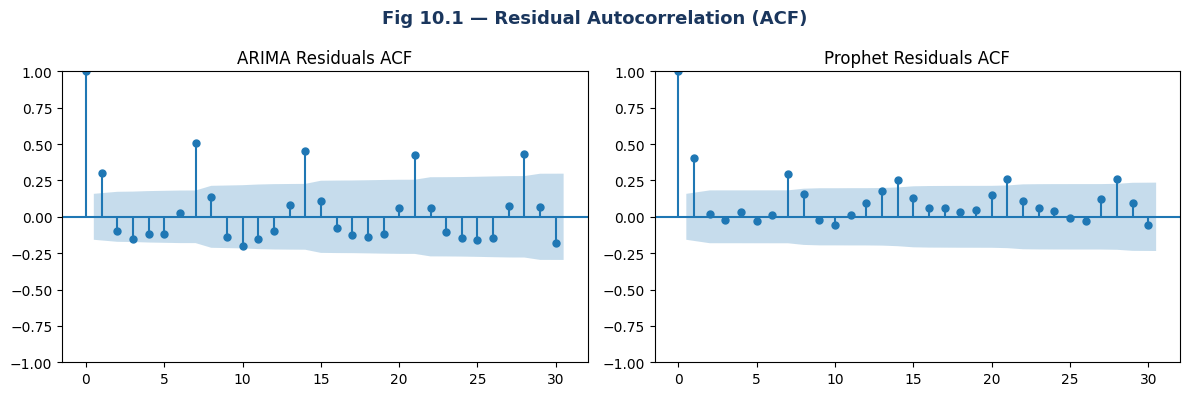

Ljung-Box test for ARIMA residuals (lag 7):


,lb_stat,lb_pvalue
7,66.058953,9.209839e-12


Ljung-Box test for Prophet residuals (lag 7):


,lb_stat,lb_pvalue
7,39.618824,0.000001


In [14]:
# §10 continued: Ljung-Box Residual Diagnostics
import statsmodels.api as sm
import matplotlib.pyplot as plt

print("--- §10 Residual Diagnostics ---")
res_arima = actuals - preds_arima
res_prophet = actuals - preds_auto

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Fig 10.1 — Residual Autocorrelation (ACF)', fontweight='bold', fontsize=13, color='#1a365d')
sm.graphics.tsa.plot_acf(res_arima, lags=30, ax=axes[0], title="ARIMA Residuals ACF")
sm.graphics.tsa.plot_acf(res_prophet, lags=30, ax=axes[1], title="Prophet Residuals ACF")
plt.tight_layout()
plt.savefig('assets/plot_residual_acf.png', dpi=300)
plt.show()

lb_arima = sm.stats.acorr_ljungbox(res_arima, lags=[7], return_df=True)
lb_prophet = sm.stats.acorr_ljungbox(res_prophet, lags=[7], return_df=True)
print("Ljung-Box test for ARIMA residuals (lag 7):")
display(lb_arima)
print("Ljung-Box test for Prophet residuals (lag 7):")
display(lb_prophet)

In [15]:
from IPython.display import display, HTML

mse_arima = np.mean((actuals - preds_arima) ** 2)
mse_prophet = np.mean((actuals - preds_auto) ** 2)
lower_mse_model = "Prophet 50%" if mse_prophet < mse_arima else "ARIMA"

if dm_pval < 0.05:
    dm_conclusion = f"Reject equal predictive accuracy at 5%; {lower_mse_model} has the lower MSE in this run."
else:
    dm_conclusion = f"Fail to reject equal predictive accuracy at 5%; the observed MSE advantage for {lower_mse_model} is not statistically significant by this test."

lb_arima_p = float(lb_arima['lb_pvalue'].iloc[0])
lb_prophet_p = float(lb_prophet['lb_pvalue'].iloc[0])

def ljung_box_reading(model_name, p_value):
    if p_value < 0.05:
        return f"{model_name}: p={p_value:.4f}; residual autocorrelation remains at lag 7."
    return f"{model_name}: p={p_value:.4f}; no significant residual autocorrelation is detected at lag 7."

residual_conclusion = (
    "Prophet has the higher lag-7 Ljung-Box p-value."
    if lb_prophet_p > lb_arima_p
    else "ARIMA has the higher lag-7 Ljung-Box p-value."
)

display(HTML(f"""
<div style="background:#ebf8ff;border-left:6px solid #2b6cb0;padding:12px 18px;border-radius:4px">
<b style="color:#1a365d;font-size:15px">READING - DM test + Fig 10.1: statistical evidence from this run</b>
<ul style="margin:8px 0 0 0">
<li><b>Diebold-Mariano:</b> statistic={dm_stat:.3f}, p={dm_pval:.4g}. {dm_conclusion}</li>
<li><b>Ljung-Box:</b> {ljung_box_reading('ARIMA', lb_arima_p)}</li>
<li><b>Ljung-Box:</b> {ljung_box_reading('Prophet 50%', lb_prophet_p)}</li>
</ul>
<b style="color:#1a365d">Conclusion:</b> {residual_conclusion} Residual adequacy and predictive-accuracy significance are reported separately; neither is inferred from the plot alone.
</div>
"""))

## §11 Asymmetric Financial Loss: Translating Forecast Errors into Estimated Penalties

The symmetric metrics above treat every error equally. In practice, the cost structure is asymmetric:

- **Under-forecasting** -> stockout proxy -> lost margin: **EUR3.12/unit**
- **Over-forecasting** -> spoilage / disposal proxy: **EUR1.52/unit** (commercial) or **EUR1.81/unit** (ESG)

Because the public dataset does **not** contain true inventory positions, order quantities, replenishment lead times, or disposal records, understock and overstock are not directly observed. They are **forecast-based counterfactual estimates** on the 154-day test set: each strategy's forecast is treated as a stocking-quantity proxy and compared with realized sales.

For each strategy and day:

```
under_units = max(actual_sales - forecast, 0)
over_units  = max(forecast - actual_sales, 0)

under_loss = under_units * EUR3.12
over_loss  = over_units * penalty_over
```

The two tuned policies are also compared statistically using the 154 paired daily loss differences. A HAC/Newey-West standard error with lag 7 allows for weekly serial correlation. The 95% confidence interval is interpreted without an arbitrary equivalence margin:

- an interval entirely below zero supports lower loss for the 67.2% policy;
- an interval entirely above zero supports lower loss for the 63.3% policy;
- an interval containing zero means there is no statistically decisive difference in this test period.

An interval containing zero does **not** prove that the policies are equivalent; formal equivalence testing would require a defensible, pre-specified equivalence margin. The analysis remains a comparison of forecast-based policies under common assumptions, not observed inventory loss or audited operating cost.

--- Commercial Scenario (Penalty Over = 1.52, Under = 3.12) ---
ARIMA Total Loss: 6,095,789.79
Prophet 50% Total Loss: 5,289,102.12
Prophet Profit Max Total Loss: 4,836,089.51
Prophet ESG Total Loss: 4,839,022.23
Best commercial-scenario strategy: Prophet Profit Max (67.2% quantile)

--- ESG Scenario (Penalty Over = 1.81, Under = 3.12) ---
ARIMA Total Loss: 6,589,837.85
Prophet 50% Total Loss: 5,578,639.22
Prophet Profit Max Total Loss: 5,331,609.76
Prophet ESG Total Loss: 5,279,253.79
Best ESG-scenario strategy: Prophet ESG (63.3% quantile) (5,279,253.79)

--- Paired Tuned-Policy Comparison (ESG costs) ---
Mean daily loss difference (67.2% - 63.3%): EUR339.97
HAC SE (lag 7): EUR370.02 | z = 0.919
95% CI for total difference: EUR-59,328 to EUR164,040
Decision: No statistically decisive difference: the 95% confidence interval includes zero.


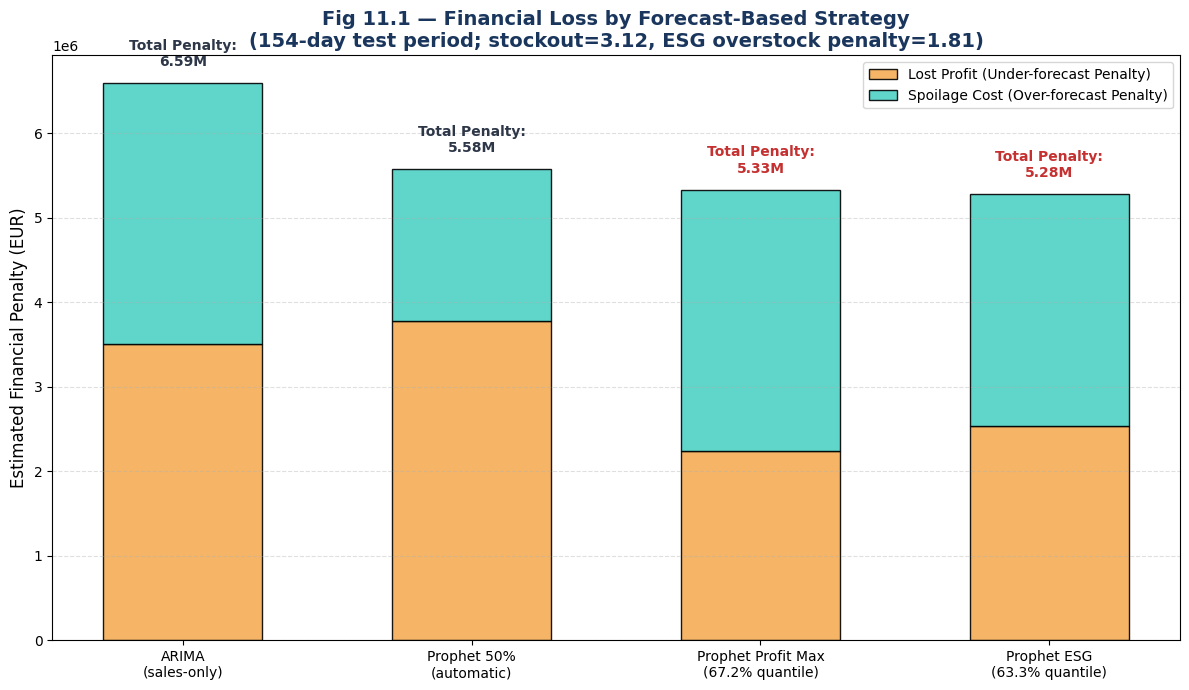

In [16]:
# Calculate daily and total asymmetric losses
def calc_daily_loss(preds, penalty_over, penalty_under):
    diff = np.asarray(preds) - np.asarray(actuals)
    under_daily = np.maximum(0, -diff) * penalty_under
    over_daily = np.maximum(0, diff) * penalty_over
    return under_daily, over_daily

def calc_absolute_loss(preds, penalty_over, penalty_under):
    under_daily, over_daily = calc_daily_loss(preds, penalty_over, penalty_under)
    return under_daily.sum(), over_daily.sum()

# 1. Commercial Scenario (PENALTY_OVER = 1.52)
print("--- Commercial Scenario (Penalty Over = 1.52, Under = 3.12) ---")
arima_under_comm, arima_over_comm = calc_absolute_loss(preds_arima, PENALTY_OVER_COMM, PENALTY_UNDER)
auto_under_comm, auto_over_comm = calc_absolute_loss(preds_auto, PENALTY_OVER_COMM, PENALTY_UNDER)
opt_under_comm, opt_over_comm = calc_absolute_loss(preds_opt, PENALTY_OVER_COMM, PENALTY_UNDER)
esg_under_comm, esg_over_comm = calc_absolute_loss(preds_esg, PENALTY_OVER_COMM, PENALTY_UNDER)

loss_arima_comm = arima_under_comm + arima_over_comm
loss_auto_comm = auto_under_comm + auto_over_comm
loss_opt_comm = opt_under_comm + opt_over_comm
loss_esg_comm = esg_under_comm + esg_over_comm

commercial_totals = {
    "ARIMA": loss_arima_comm,
    "Prophet 50%": loss_auto_comm,
    "Prophet Profit Max (67.2% quantile)": loss_opt_comm,
    "Prophet ESG (63.3% quantile)": loss_esg_comm,
}
best_commercial_strategy = min(commercial_totals, key=commercial_totals.get)

print(f"ARIMA Total Loss: {loss_arima_comm:,.2f}")
print(f"Prophet 50% Total Loss: {loss_auto_comm:,.2f}")
print(f"Prophet Profit Max Total Loss: {loss_opt_comm:,.2f}")
print(f"Prophet ESG Total Loss: {loss_esg_comm:,.2f}")
print(f"Best commercial-scenario strategy: {best_commercial_strategy}")

# 2. ESG Scenario (PENALTY_OVER = 1.81)
print("\n--- ESG Scenario (Penalty Over = 1.81, Under = 3.12) ---")
arima_under_esg, arima_over_esg = calc_absolute_loss(preds_arima, PENALTY_OVER_ESG, PENALTY_UNDER)
auto_under_esg, auto_over_esg = calc_absolute_loss(preds_auto, PENALTY_OVER_ESG, PENALTY_UNDER)
opt_under_esg, opt_over_esg = calc_absolute_loss(preds_opt, PENALTY_OVER_ESG, PENALTY_UNDER)
esg_under_esg, esg_over_esg = calc_absolute_loss(preds_esg, PENALTY_OVER_ESG, PENALTY_UNDER)

loss_arima_esg = arima_under_esg + arima_over_esg
loss_auto_esg = auto_under_esg + auto_over_esg
loss_opt_esg = opt_under_esg + opt_over_esg
loss_esg_esg = esg_under_esg + esg_over_esg

esg_totals = {
    "ARIMA": loss_arima_esg,
    "Prophet 50%": loss_auto_esg,
    "Prophet Profit Max (67.2% quantile)": loss_opt_esg,
    "Prophet ESG (63.3% quantile)": loss_esg_esg,
}
best_esg_strategy = min(esg_totals, key=esg_totals.get)
best_esg_loss = esg_totals[best_esg_strategy]

print(f"ARIMA Total Loss: {loss_arima_esg:,.2f}")
print(f"Prophet 50% Total Loss: {loss_auto_esg:,.2f}")
print(f"Prophet Profit Max Total Loss: {loss_opt_esg:,.2f}")
print(f"Prophet ESG Total Loss: {loss_esg_esg:,.2f}")
print(f"Best ESG-scenario strategy: {best_esg_strategy} ({best_esg_loss:,.2f})")

# Paired statistical comparison of the two tuned policies under ESG costs.
# Difference is Profit Max daily loss minus ESG daily loss: negative favours 67.2%.
import statsmodels.api as sm
from scipy.stats import norm

opt_under_daily, opt_over_daily = calc_daily_loss(preds_opt, PENALTY_OVER_ESG, PENALTY_UNDER)
esg_under_daily, esg_over_daily = calc_daily_loss(preds_esg, PENALTY_OVER_ESG, PENALTY_UNDER)
paired_loss_diff = (opt_under_daily + opt_over_daily) - (esg_under_daily + esg_over_daily)

hac_fit = sm.OLS(paired_loss_diff, np.ones(len(paired_loss_diff))).fit(
    cov_type='HAC', cov_kwds={'maxlags': 7}
)
mean_daily_diff = float(hac_fit.params[0])
hac_se = float(hac_fit.bse[0])
z_score = mean_daily_diff / hac_se if hac_se > 0 else np.nan

ci95_daily = (
    mean_daily_diff - norm.ppf(0.975) * hac_se,
    mean_daily_diff + norm.ppf(0.975) * hac_se,
)
ci95_total = tuple(bound * len(paired_loss_diff) for bound in ci95_daily)

if ci95_daily[1] < 0:
    policy_decision = "Prophet Profit Max (67.2%) has statistically lower loss at the 5% level."
elif ci95_daily[0] > 0:
    policy_decision = "Prophet ESG (63.3%) has statistically lower loss at the 5% level."
else:
    policy_decision = "No statistically decisive difference: the 95% confidence interval includes zero."

print("\n--- Paired Tuned-Policy Comparison (ESG costs) ---")
print(f"Mean daily loss difference (67.2% - 63.3%): EUR{mean_daily_diff:,.2f}")
print(f"HAC SE (lag 7): EUR{hac_se:,.2f} | z = {z_score:.3f}")
print(f"95% CI for total difference: EUR{ci95_total[0]:,.0f} to EUR{ci95_total[1]:,.0f}")
print(f"Decision: {policy_decision}")

# Plot Stacked Bar Chart for ESG Scenario (Fig 11.1)
# Poster-facing comparison: forecast-based strategies only.
models = ['ARIMA\n(sales-only)', 'Prophet 50%\n(automatic)', 'Prophet Profit Max\n(67.2% quantile)', 'Prophet ESG\n(63.3% quantile)']
under_losses = [arima_under_esg, auto_under_esg, opt_under_esg, esg_under_esg]
over_losses = [arima_over_esg, auto_over_esg, opt_over_esg, esg_over_esg]
total_losses = [loss_arima_esg, loss_auto_esg, loss_opt_esg, loss_esg_esg]

fig, ax = plt.subplots(figsize=(12, 7))
bar_width = 0.55
ax.bar(models, under_losses, width=bar_width, label='Lost Profit (Under-forecast Penalty)', color='#f6ad55', edgecolor='black', alpha=0.9)
ax.bar(models, over_losses, width=bar_width, bottom=under_losses, label='Spoilage Cost (Over-forecast Penalty)', color='#4fd1c5', edgecolor='black', alpha=0.9)

ax.set_title('Fig 11.1 — Financial Loss by Forecast-Based Strategy\n(154-day test period; stockout=3.12, ESG overstock penalty=1.81)', fontweight='bold', fontsize=14, color='#1a365d')
ax.set_ylabel('Estimated Financial Penalty (EUR)', fontsize=12)
ax.legend(loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.4)

if ci95_daily[1] < 0:
    statistically_supported_indices = {2}
elif ci95_daily[0] > 0:
    statistically_supported_indices = {3}
else:
    statistically_supported_indices = {2, 3}
for i, total in enumerate(total_losses):
    color = '#c53030' if i in statistically_supported_indices else '#2d3748'
    ax.text(i, total + (max(total_losses)*0.025), f'Total Penalty:\n{total/1e6:.2f}M', ha='center', va='bottom', fontweight='bold', color=color)

plt.tight_layout()
plt.savefig('assets/financial_bar_chart.png', dpi=300)
plt.show()

In [17]:
from IPython.display import display, HTML

loss_rows = [
    ("ARIMA", loss_arima_esg),
    ("Prophet 50%", loss_auto_esg),
    ("Prophet Profit Max (67.2%)", loss_opt_esg),
    ("Prophet ESG (63.3%)", loss_esg_esg),
]
loss_items = "".join(
    f"<li><b>{name}:</b> EUR{value/1e6:.3f}M</li>"
    for name, value in loss_rows
)

best_esg_strategy = min(esg_totals, key=esg_totals.get)
best_esg_loss = esg_totals[best_esg_strategy]
best_tuned_name, best_tuned_loss = min(
    [("Prophet Profit Max (67.2%)", loss_opt_esg), ("Prophet ESG (63.3%)", loss_esg_esg)],
    key=lambda item: item[1],
)
tuned_gap = abs(loss_opt_esg - loss_esg_esg)
tuned_gap_pct = tuned_gap / min(loss_opt_esg, loss_esg_esg) * 100
gain_vs_auto = loss_auto_esg - best_tuned_loss
gain_vs_arima = loss_arima_esg - best_esg_loss
numeric_direction = (
    "67.2% is numerically lower"
    if loss_opt_esg < loss_esg_esg
    else "63.3% is numerically lower"
)

display(HTML(f"""
<div style="background:#f0fff4;border-left:6px solid #25855a;padding:12px 18px;border-radius:4px">
<b style="color:#22543d;font-size:16px">READING - Fig 11.1: ESG-scenario losses from this run</b>
<ul style="margin:8px 0 0 0">
{loss_items}
<li><b>Numerically lowest tested strategy:</b> {best_esg_strategy} at EUR{best_esg_loss/1e6:.3f}M.</li>
<li><b>Best tuned policy vs Prophet 50%:</b> EUR{gain_vs_auto/1e6:.3f}M lower estimated loss.</li>
<li><b>67.2% vs 63.3% numerical gap:</b> {numeric_direction} by EUR{tuned_gap:,.0f} ({tuned_gap_pct:.2f}% of the lower tuned loss).</li>
<li><b>Paired HAC comparison:</b> z={z_score:.3f}; 95% CI for the total difference (67.2% - 63.3%) is EUR{ci95_total[0]:,.0f} to EUR{ci95_total[1]:,.0f}.</li>
</ul>
<b style="color:#22543d">Conclusion:</b> {policy_decision} Exact totals are retained for transparency, but a numerical ordering is not promoted into a scientific winner unless the paired 95% confidence interval excludes zero.
</div>
"""))

## §12 Detailed Forecast-Strategy Metrics (ESG Scenario)

The table below summarizes each forecast-based strategy's under-forecast volume, over-forecast volume, observed-sales coverage proxy, and total estimated penalty under the ESG cost scenario. This is not an observed inventory table; it is a transparent translation of forecast errors into operational quantities.


In [18]:
# --- Auditable Evidence: Detailed Forecast-Strategy Metrics (ESG Scenario) ---
# Using the test predictions and actual sales, we compute under-forecast and
# over-forecast quantities for each forecast-based strategy.
import pandas as pd

print("--- Detailed Forecast-Strategy Metrics (ESG Scenario) ---")
total_observed_sales = np.sum(actuals)

def forecast_strategy_row(strategy, preds, under_loss, over_loss, total_loss):
    diff = np.asarray(preds) - np.asarray(actuals)
    under_units = np.sum(np.maximum(0, -diff))
    over_units = np.sum(np.maximum(0, diff))
    coverage_proxy = (total_observed_sales - under_units) / total_observed_sales
    return {
        "Strategy": strategy,
        "Observed-sales coverage proxy": f"{coverage_proxy*100:.2f}%",
        "Under-forecast (Units)": f"{under_units:,.0f}",
        "Over-forecast (Units)": f"{over_units:,.0f}",
        "Total Penalty": f"€{total_loss/1e6:.2f}M",
    }

metrics_summary = [
    forecast_strategy_row("ARIMA Benchmark", preds_arima, arima_under_esg, arima_over_esg, loss_arima_esg),
    forecast_strategy_row("Prophet 50% Automatic", preds_auto, auto_under_esg, auto_over_esg, loss_auto_esg),
    forecast_strategy_row("Prophet Profit Max (67.2%)", preds_opt, opt_under_esg, opt_over_esg, loss_opt_esg),
    forecast_strategy_row("Prophet ESG (63.3%)", preds_esg, esg_under_esg, esg_over_esg, loss_esg_esg),
]

df_operational_metrics = pd.DataFrame(metrics_summary)
display(df_operational_metrics)

--- Detailed Forecast-Strategy Metrics (ESG Scenario) ---


,Strategy,Observed-sales coverage proxy,Under-forecast (Units),Over-forecast (Units),Total Penalty
0,ARIMA Benchmark,95.85%,"1,123,813","1,703,614",€6.59M
1,Prophet 50% Automatic,95.53%,"1,208,823","998,404",€5.58M
2,Prophet Profit Max (67.2%),97.35%,"717,590","1,708,691",€5.33M
3,Prophet ESG (63.3%),97.00%,"811,411","1,518,040",€5.28M


## §13 Assumption Sensitivity Analysis

The results above depend on scenario cost parameters, especially the understock penalty (lost margin) and the overstock penalty (spoilage / disposal). Because the public Rohlik dataset does **not** include internal margin, inventory, disposal, or accounting records, these values are not Rohlik-confirmed estimates. They are transparent stress-test assumptions.

The four sensitivity scenarios are chosen to vary the two main business levers around the base ESG case. The range is deliberately bounded: it does not reverse the business logic by making overstock more expensive than understock. Across all four cases, understock remains the larger penalty, while the margin and waste-cost assumptions move within transparent illustrative stress-test bands.

| Scenario | Understock penalty | Overstock penalty | Interpretation |
|---|---:|---:|---|
| Conservative | EUR2.08 | EUR1.20 | Lower-margin, lower-waste-cost case. EUR2.08 equals a 20% margin on the approximate EUR10.40 average selling price. |
| Base ESG | EUR3.12 | EUR1.81 | Main ESG case used in §11. EUR3.12 equals a 30% margin on EUR10.40; EUR1.81 = EUR1.52 spoilage + EUR0.29 ESG disposal surcharge. |
| High Waste Cost | EUR3.12 | EUR2.50 | Same lost-margin assumption as Base ESG, but a higher waste / disposal penalty. |
| High Stockout Cost | EUR4.16 | EUR1.81 | Same ESG overstock penalty as Base ESG, but a higher lost-margin assumption. EUR4.16 equals a 40% margin on EUR10.40. |

This section does **not** re-train new models or re-optimise a new quantile for each scenario. It keeps the four forecast strategies fixed (ARIMA, Prophet 50%, Prophet 67.2%, Prophet 63.3%) and re-prices their forecast-based understock/overstock quantities under alternative cost assumptions.

This is intentional. Re-optimising a new newsvendor quantile for every sensitivity scenario would answer a different question: *what new policy should we choose if the cost ratio changes?* Here the question is narrower: *does the main Prophet-vs-ARIMA conclusion survive if the uncertain cost penalties are moved within a reasonable range?* Therefore, §13 is a sensitivity test of the evaluated strategies, not a second optimisation stage. The `implied_newsvendor_quantile` column is included only to show how each cost ratio would shift the theoretical target quantile.

For each scenario, the exact numerical minimum is reported separately from the 67.2%-vs-63.3% statistical comparison. The latter uses the paired daily loss difference and a lag-7 HAC 95% confidence interval. If that interval includes zero, the notebook reports no statistically decisive difference rather than forcing a tuned-policy winner.

For each scenario, the exact numerical minimum is reported separately from the 67.2%-vs-63.3% statistical comparison. The latter uses the paired daily loss difference and a lag-7 HAC 95% confidence interval. If that interval includes zero, the notebook reports no statistically decisive difference rather than forcing a tuned-policy winner.

--- Assumption Sensitivity Analysis (Table 13.1) ---


,scenario,understock_penalty,overstock_penalty,implied_newsvendor_quantile,numerically_lowest_model,tuned_mean_difference_m,tuned_95ci_low_m,tuned_95ci_high_m,tuned_statistical_result,rationale,ARIMA_loss_m,Prophet_Baseline_loss_m,Prophet_Profit_Max_loss_m,Prophet_ESG_loss_m
0,Conservative,2.08,1.20,63.4%,Prophet ESG,0.033633,-0.040669,0.107935,No statistically decisive difference,20% margin on approx. EUR10.40 ASP; low waste-...,4.38,3.71,3.54,3.51
1,Base ESG,3.12,1.81,63.3%,Prophet ESG,0.052356,-0.059328,0.164040,No statistically decisive difference,30% margin on approx. EUR10.40 ASP; EUR1.52 sp...,6.59,5.58,5.33,5.28
2,High Waste Cost,3.12,2.50,55.5%,Prophet 50%,0.183905,0.056281,0.311529,63.3% statistically lower loss,Base lost-margin assumption; higher waste/disp...,7.77,6.27,6.51,6.33
3,High Stockout Cost,4.16,1.81,69.7%,Prophet Profit Max,-0.045218,-0.180217,0.089781,No statistically decisive difference,40% margin on approx. EUR10.40 ASP; base ESG o...,7.76,6.84,6.08,6.12


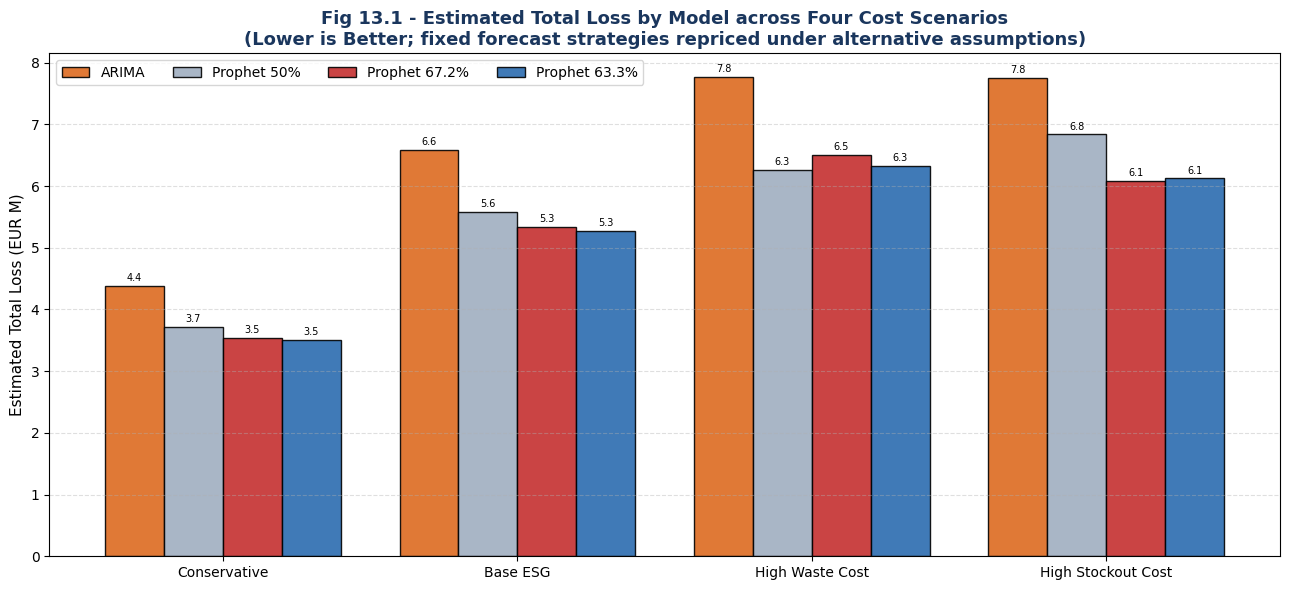

In [19]:
# --- Auditable Evidence: Assumption Sensitivity Analysis ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import norm

scenarios = [
    {
        "name": "Conservative",
        "under": 2.08,
        "over": 1.20,
        "rationale": "20% margin on approx. EUR10.40 ASP; low waste-cost assumption",
    },
    {
        "name": "Base ESG",
        "under": 3.12,
        "over": 1.81,
        "rationale": "30% margin on approx. EUR10.40 ASP; EUR1.52 spoilage + EUR0.29 ESG disposal surcharge",
    },
    {
        "name": "High Waste Cost",
        "under": 3.12,
        "over": 2.50,
        "rationale": "Base lost-margin assumption; higher waste/disposal penalty",
    },
    {
        "name": "High Stockout Cost",
        "under": 4.16,
        "over": 1.81,
        "rationale": "40% margin on approx. EUR10.40 ASP; base ESG overstock penalty",
    },
]

sensitivity_results = []

for sc in scenarios:
    p_u = sc["under"]
    p_o = sc["over"]

    arima_u, arima_o = calc_absolute_loss(preds_arima, p_o, p_u)
    p_base_u, p_base_o = calc_absolute_loss(preds_auto, p_o, p_u)
    p_opt_u, p_opt_o = calc_absolute_loss(preds_opt, p_o, p_u)
    p_esg_u, p_esg_o = calc_absolute_loss(preds_esg, p_o, p_u)

    arima_t = arima_u + arima_o
    p_base_t = p_base_u + p_base_o
    p_opt_t = p_opt_u + p_opt_o
    p_esg_t = p_esg_u + p_esg_o

    # Strict Audit Check: Ensure the Base ESG scenario perfectly reconciles with the main calculations
    if sc["name"] == "Base ESG":
        assert abs(arima_t - loss_arima_esg) < 1, "ARIMA mismatch"
        assert abs(p_base_t - loss_auto_esg) < 1, "Prophet Auto mismatch"
        assert abs(p_opt_t - loss_opt_esg) < 1, "Prophet Opt mismatch"
        assert abs(p_esg_t - loss_esg_esg) < 1, "Prophet ESG mismatch"

    totals = {
        "ARIMA": arima_t,
        "Prophet 50%": p_base_t,
        "Prophet Profit Max": p_opt_t,
        "Prophet ESG": p_esg_t
    }
    numerically_lowest_model = min(totals, key=totals.get)

    # Statistical comparison of the two tuned policies under this cost scenario.
    opt_u_daily, opt_o_daily = calc_daily_loss(preds_opt, p_o, p_u)
    esg_u_daily, esg_o_daily = calc_daily_loss(preds_esg, p_o, p_u)
    tuned_diff_daily = (opt_u_daily + opt_o_daily) - (esg_u_daily + esg_o_daily)
    tuned_hac = sm.OLS(tuned_diff_daily, np.ones(len(tuned_diff_daily))).fit(
        cov_type='HAC', cov_kwds={'maxlags': 7}
    )
    tuned_mean_daily = float(tuned_hac.params[0])
    tuned_hac_se = float(tuned_hac.bse[0])
    tuned_ci95_daily = (
        tuned_mean_daily - norm.ppf(0.975) * tuned_hac_se,
        tuned_mean_daily + norm.ppf(0.975) * tuned_hac_se,
    )
    tuned_ci95_total = tuple(bound * len(tuned_diff_daily) for bound in tuned_ci95_daily)
    if tuned_ci95_daily[1] < 0:
        tuned_statistical_result = "67.2% statistically lower loss"
    elif tuned_ci95_daily[0] > 0:
        tuned_statistical_result = "63.3% statistically lower loss"
    else:
        tuned_statistical_result = "No statistically decisive difference"

    sensitivity_results.append({
        "scenario": sc["name"],
        "understock_penalty": p_u,
        "overstock_penalty": p_o,
        "implied_newsvendor_quantile": p_u / (p_u + p_o),
        "numerically_lowest_model": numerically_lowest_model,
        "tuned_mean_difference_m": tuned_mean_daily * len(tuned_diff_daily) / 1e6,
        "tuned_95ci_low_m": tuned_ci95_total[0] / 1e6,
        "tuned_95ci_high_m": tuned_ci95_total[1] / 1e6,
        "tuned_statistical_result": tuned_statistical_result,
        "rationale": sc["rationale"],
        "ARIMA_loss_m": arima_t / 1e6,
        "Prophet_Baseline_loss_m": p_base_t / 1e6,
        "Prophet_Profit_Max_loss_m": p_opt_t / 1e6,
        "Prophet_ESG_loss_m": p_esg_t / 1e6
    })

df_sensitivity = pd.DataFrame(sensitivity_results)
df_sensitivity_display = df_sensitivity.copy()
df_sensitivity_display["implied_newsvendor_quantile"] = df_sensitivity_display["implied_newsvendor_quantile"].map(lambda x: f"{x:.1%}")
loss_cols = ["ARIMA_loss_m", "Prophet_Baseline_loss_m", "Prophet_Profit_Max_loss_m", "Prophet_ESG_loss_m"]
df_sensitivity_display[loss_cols] = df_sensitivity_display[loss_cols].round(2)

print("--- Assumption Sensitivity Analysis (Table 13.1) ---")
display(df_sensitivity_display)

# --- Fig 13.1: Grouped bar chart ---
scenario_names = [r["scenario"] for r in sensitivity_results]
model_cols = ["ARIMA_loss_m", "Prophet_Baseline_loss_m", "Prophet_Profit_Max_loss_m", "Prophet_ESG_loss_m"]
model_labels = ["ARIMA", "Prophet 50%", "Prophet 67.2%", "Prophet 63.3%"]
model_colors = ["#dd6b20", "#a0aec0", "#c53030", "#2b6cb0"]

x = np.arange(len(scenario_names))
width = 0.20

fig, ax = plt.subplots(figsize=(13, 6))
for j, (col, lab, colr) in enumerate(zip(model_cols, model_labels, model_colors)):
    vals = [r[col] for r in sensitivity_results]
    bars = ax.bar(x + (j - 1.5) * width, vals, width, label=lab, color=colr, edgecolor='black', alpha=0.9)
    for b in bars:
        ax.annotate(f'{b.get_height():.1f}', xy=(b.get_x() + b.get_width()/2, b.get_height()),
                    xytext=(0, 2), textcoords="offset points", ha='center', va='bottom', fontsize=7)

ax.set_title('Fig 13.1 - Estimated Total Loss by Model across Four Cost Scenarios\n(Lower is Better; fixed forecast strategies repriced under alternative assumptions)',
             fontweight='bold', fontsize=13, color='#1a365d')
ax.set_ylabel('Estimated Total Loss (EUR M)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(scenario_names, fontsize=10)
ax.legend(loc='upper left', ncol=4)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('assets/plot_sensitivity.png', dpi=300)
plt.show()

In [20]:
from IPython.display import display, HTML

scenario_winners = dict(zip(df_sensitivity['scenario'], df_sensitivity['numerically_lowest_model']))
tuned_statistical_results = dict(zip(df_sensitivity['scenario'], df_sensitivity['tuned_statistical_result']))
scenario_items = "".join(
    f"<li><b>{scenario}:</b> numerical minimum = {scenario_winners[scenario]}; tuned-policy inference = {tuned_statistical_results[scenario]}.</li>"
    for scenario in scenario_winners
)

prophet_cols = [
    'Prophet_Baseline_loss_m',
    'Prophet_Profit_Max_loss_m',
    'Prophet_ESG_loss_m',
]
all_prophet_below_arima = bool(
    (df_sensitivity[prophet_cols].max(axis=1) < df_sensitivity['ARIMA_loss_m']).all()
)
robustness_statement = (
    "Every tested Prophet strategy remains below ARIMA in all four scenarios."
    if all_prophet_below_arima
    else "At least one Prophet strategy does not remain below ARIMA in every scenario; inspect Table 13.1 before making a robustness claim."
)

decisive_count = sum(result != "No statistically decisive difference" for result in tuned_statistical_results.values())

display(HTML(f"""
<div style="background:#ebf8ff;border-left:6px solid #2b6cb0;padding:12px 18px;border-radius:4px">
<b style="color:#1a365d;font-size:15px">READING - Fig 13.1 + Table 13.1: sensitivity results from this run</b>
<ul style="margin:8px 0 0 0">
{scenario_items}
<li><b>Prophet vs ARIMA robustness:</b> {robustness_statement}</li>
<li><b>Tuned-policy evidence:</b> {decisive_count} of {len(tuned_statistical_results)} scenarios show a statistically decisive 67.2%-vs-63.3% difference at the 5% level.</li>
</ul>
<b style="color:#1a365d">Conclusion:</b> these are fixed-policy stress tests, not re-optimised models. Exact numerical minima remain visible, while the paired HAC interval determines whether the two tuned policies are statistically distinguishable.
</div>
"""))

## §14 Scope of Inference and Data Limitations

- The raw public data contain sales, availability, product categories, calendar variables, prices, and discounts, but **not** true inventory-position data such as on-hand stock, order quantities, replenishment lead times, or disposal records.
- Because true inventory and accounting data are unavailable, this notebook does not claim Rohlik's actual operating cost or actual savings.
- Financial penalties are scenario assumptions applied consistently to forecast errors: under-forecasting is treated as lost margin, and over-forecasting is treated as spoilage / disposal cost.
- The analysis is valid as forecast-based decision-support evidence, but real deployment would require Rohlik's internal inventory, lead-time, replenishment, margin, disposal, and substitution data.

Therefore, the results should be interpreted as evidence that forecast-aware, cost-based policies can improve the estimated penalty among tested forecasting strategies, not as a verified accounting estimate of Rohlik's realized savings.


## §15 Export Deliverables

We save the final forecast-strategy P&L losses as a JSON file, bundle all generated visual assets into a single zip file (`forecasting_decision_support_assets.zip`), and trigger the download.


In [21]:
# §15 Export Deliverables: JSON + Zip + Download
import zipfile

# 1. Save final forecast-strategy P&L losses as JSON
esg_totals_export = {
    "ARIMA": loss_arima_esg,
    "Prophet 50%": loss_auto_esg,
    "Prophet Profit Max (67.2% quantile)": loss_opt_esg,
    "Prophet ESG (63.3% quantile)": loss_esg_esg,
}
best_esg_strategy_export = min(esg_totals_export, key=esg_totals_export.get)
best_esg_penalty_export = esg_totals_export[best_esg_strategy_export]

pnl = {
    "test_horizon_days": 154,
    "test_period": "2024-01-01 to 2024-06-02",
    "arima_esg_penalty": round(loss_arima_esg, 2),
    "prophet_50_esg_penalty": round(loss_auto_esg, 2),
    "prophet_profit_max_esg_penalty": round(loss_opt_esg, 2),
    "prophet_esg_penalty": round(loss_esg_esg, 2),
    "best_esg_strategy": best_esg_strategy_export,
    "best_esg_penalty": round(best_esg_penalty_export, 2),
    "tuned_policy_mean_difference_67_minus_63": round(mean_daily_diff * len(paired_loss_diff), 2),
    "tuned_policy_hac_se_daily": round(hac_se, 4),
    "tuned_policy_z_score": round(z_score, 4),
    "tuned_policy_95ci_total": [round(ci95_total[0], 2), round(ci95_total[1], 2)],
    "tuned_policy_statistical_decision": policy_decision,
    "best_tuned_delta_vs_prophet_50": round(loss_auto_esg - min(loss_opt_esg, loss_esg_esg), 2),
    "best_tuned_delta_pct_vs_prophet_50": round((loss_auto_esg - min(loss_opt_esg, loss_esg_esg)) / loss_auto_esg * 100, 1),
    "prophet_profit_max_delta_vs_prophet_esg": round(loss_esg_esg - loss_opt_esg, 2),
    "best_prophet_delta_vs_arima": round(loss_arima_esg - best_esg_penalty_export, 2),
    "best_prophet_delta_pct_vs_arima": round((loss_arima_esg - best_esg_penalty_export) / loss_arima_esg * 100, 1),
}

with open("assets/final_pnl.json", "w") as f:
    json.dump(pnl, f, indent=2)

print("Saved assets/final_pnl.json")
print(f"Best ESG-scenario strategy: {best_esg_strategy_export}")

# 2. Bundle all generated visual assets into forecasting_decision_support_assets.zip
zip_path = "forecasting_decision_support_assets.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    zf.write("assets/final_pnl.json", arcname="final_pnl.json")
    asset_files = [
        "assets/plot_eda_correlation.png",
        "assets/prophet_components_native.png",
        "assets/plot_training_fit.png",
        "assets/plot_arima_vs_prophet.png",
        "assets/plot_3way_test.png",
        "assets/plot_optimization_curve.png",
        "assets/plot_symmetric_metrics.png",
        "assets/plot_residual_acf.png",
        "assets/financial_bar_chart.png",
        "assets/plot_sensitivity.png",
    ]
    for f in asset_files:
        if os.path.exists(f):
            zf.write(f, arcname=os.path.basename(f))
            print("  + {}".format(os.path.basename(f)))
        else:
            print("  ! {} not found — skipping".format(f))

print("\nBundle complete: {} ({} bytes)".format(zip_path, os.path.getsize(zip_path)))

# 3. Trigger download (Colab) or print path (local)
try:
    from google.colab import files
    files.download(zip_path)
except ImportError:
    print("Download ready at: {}/{}".format(os.getcwd(), zip_path))

Saved assets/final_pnl.json
Best ESG-scenario strategy: Prophet ESG (63.3% quantile)
  + plot_eda_correlation.png
  + prophet_components_native.png
  + plot_training_fit.png
  + plot_arima_vs_prophet.png
  + plot_3way_test.png
  + plot_optimization_curve.png
  + plot_symmetric_metrics.png
  + plot_residual_acf.png
  + financial_bar_chart.png
  + plot_sensitivity.png

Bundle complete: forecasting_decision_support_assets.zip (3489977 bytes)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## §16 Reporting Conventions and Interpretation Guidance

All reported figures use the 154-day out-of-sample horizon (2024-01-01 to 2024-06-02). Cost parameters are transparent scenario assumptions, sensitivity-tested in §13. The stocking policy is a single-period newsvendor-inspired target-quantile heuristic, not a full inventory-management model.

Exact loss totals and the numerically lowest strategy are reported for transparency. The 67.2%-vs-63.3% conclusion is based on a paired daily loss difference with a lag-7 HAC/Newey-West standard error and a two-sided 95% confidence interval:

- interval entirely below zero: 67.2% has statistically lower loss;
- interval entirely above zero: 63.3% has statistically lower loss;
- interval containing zero: no statistically decisive difference.

A confidence interval containing zero **does not prove equivalence**. Formal equivalence testing would require a defensible equivalence margin specified before seeing the results, so this notebook does not make an equivalence claim.

Since the public raw data do not contain true inventory positions, order quantities, lead times, disposal records, or internal accounting records, the final report should compare forecast-based stocking policies only and avoid claims about Rohlik's actual operating cost. Understock and overstock are forecast-vs-realized-sales counterfactual estimates, not observed inventory outcomes.

## §17 References

- Rohlik Group. (2024). *Rohlik Sales Forecasting Challenge V2 public dataset*. Kaggle.
- Arrow, K. J., Harris, T., & Marschak, J. (1951). Optimal inventory policy. *Econometrica*.
- Taylor, S. J., & Letham, B. (2018). Forecasting at scale. *The American Statistician*.
- Makridakis, S. (1993). Accuracy measures: theoretical and practical concerns. *International Journal of Forecasting*.
- Diebold, F. X., & Mariano, R. S. (1995). Comparing predictive accuracy. *Journal of Business & Economic Statistics*.
- Wooldridge, J. M. (2015). *Introductory Econometrics: A Modern Approach*. Cengage Learning.
